# 🌾 Wheat Leaf Disease — EfficientNet All Models

| | |
|---|---|
| **Dataset** | Wheat Leaf Disease · 5 classes |
| **Models** | EfficientNet V1 (B0–B7) + V2 (B0,B1,B2,B3,S,M,L) = **15 models** |
| **Classes** | Brown Rust · Healthy · Loose Smut · Septoria · Yellow Rust |

---
### 📋 Table of Contents
1. [Environment Setup](#section1) — imports, config, model registry *(run every session)*
2. [Data Pipeline](#section2) — transforms, dataloaders, sanity check
3. [Core Functions](#section3) — model builder, train/eval loop
4. [Train All Models](#section4) — checkpoint-aware, auto-saves results
5. [Metrics Computation](#section5) — detailed per-model metrics
6. [Results Table](#section6) — styled comparison dataframe
7. [Visualizations](#section7) — charts, heatmaps, confusion matrices
8. [Final Verdict](#section8) — best model per metric

---
> ⚡ **Session resume tip:** After a session restart, just run **Section 1** then jump directly
> to whichever section you need. Trained models and metrics are loaded from disk automatically.

<a id='section1'></a>
---
## 🔧 Section 1 — Environment Setup
> ▶️ **Run this entire section at the start of every session (takes ~5 seconds).**

In [1]:
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '1'  # use free GPU

In [2]:
# ─────────────────────────────────────────────────────────────────
#  1.1  Dependency Check
#  Installs any missing packages automatically
# ─────────────────────────────────────────────────────────────────
import importlib, subprocess, sys

REQUIRED_PACKAGES = {
    'torch'       : 'torch',
    'torchvision' : 'torchvision',
    'sklearn'     : 'scikit-learn',
    'matplotlib'  : 'matplotlib',
    'seaborn'     : 'seaborn',
    'pandas'      : 'pandas',
    'numpy'       : 'numpy',
    'PIL'         : 'Pillow',
    'tqdm'        : 'tqdm',
}

missing = [pip for imp, pip in REQUIRED_PACKAGES.items()
           if importlib.util.find_spec(imp) is None]

if missing:
    print(f'Installing: {missing}')
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', *missing, '-q'])

print('✅ All dependencies ready')

✅ All dependencies ready


In [3]:
# ─────────────────────────────────────────────────────────────────
#  1.2  Imports
# ─────────────────────────────────────────────────────────────────
import os, random, json, time, shutil

import numpy             as np
import pandas            as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn           as sns
from PIL             import Image
from tqdm.notebook   import tqdm

import torch
import torch.nn            as nn
import torch.nn.functional as F
import torch.optim         as optim
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.utils.data         import DataLoader, WeightedRandomSampler, Subset
from torchvision              import datasets, transforms, models

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix, f1_score, precision_score, recall_score,
    accuracy_score, balanced_accuracy_score,
    matthews_corrcoef, cohen_kappa_score, roc_auc_score
)
from sklearn.preprocessing import label_binarize

print('✅ All imports successful')

✅ All imports successful


In [4]:
# ─────────────────────────────────────────────────────────────────
#  1.3  GPU Check + Auto Batch-Size Scaling
#
#  Automatically scales batch sizes based on available VRAM:
#    ≥ 40 GB (A100)  →  large batches, fast training
#    ≥ 16 GB (V100)  →  medium batches
#    <  16 GB        →  conservative batches (original Kaggle values)
# ─────────────────────────────────────────────────────────────────
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {device}')

if torch.cuda.is_available():
    gpu_name = torch.cuda.get_device_name(0)
    vram_gb  = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f'GPU    : {gpu_name}')
    print(f'VRAM   : {vram_gb:.1f} GB')

    if vram_gb >= 40:          # A100 80GB / A100 40GB
        GPU_TIER      = 'A100'
        BASE_BATCH    = 32
        LARGE_BATCH   = 16     # B5/B6/B7/V2-M/V2-L
        XLARGE_BATCH  = 12     # V2-L
        NUM_WORKERS   = 4
    elif vram_gb >= 16:        # V100 32GB / V100 16GB
        GPU_TIER      = 'V100'
        BASE_BATCH    = 24
        LARGE_BATCH   = 12
        XLARGE_BATCH  = 8
        NUM_WORKERS   = 4
    else:                      # T4 / smaller
        GPU_TIER      = 'T4'
        BASE_BATCH    = 16
        LARGE_BATCH   = 8
        XLARGE_BATCH  = 4
        NUM_WORKERS   = 2

    print(f'\nGPU Tier    : {GPU_TIER}')
    print(f'Base batch  : {BASE_BATCH}  |  Large batch: {LARGE_BATCH}  |  XLarge batch: {XLARGE_BATCH}')
    print(f'Num workers : {NUM_WORKERS}')
else:
    print('⚠️  No GPU found — training will be very slow on CPU')
    GPU_TIER, BASE_BATCH, LARGE_BATCH, XLARGE_BATCH, NUM_WORKERS = 'CPU', 8, 4, 2, 0

Device : cuda
GPU    : NVIDIA RTX PRO 6000 Blackwell Workstation Edition
VRAM   : 102.0 GB

GPU Tier    : A100
Base batch  : 32  |  Large batch: 16  |  XLarge batch: 12
Num workers : 4


In [5]:
# ─────────────────────────────────────────────────────────────────
#  1.4  ✏️  CONFIG  —  Edit paths here only
#  Batch sizes and num_workers are set automatically by GPU tier above
# ─────────────────────────────────────────────────────────────────

# ── Set these two paths to match your Jupyter environment ────────
DATA_DIR       = '/home/jupyter-kritika/wheat-project/data/Dataset'
CHECKPOINT_DIR = '/home/jupyter-kritika/wheat-project/checkpoints'    # where .pth model files are saved
# ─────────────────────────────────────────────────────────────────

CONFIG = {
    # Paths
    'data_dir'       : DATA_DIR,
    'save_dir'       : CHECKPOINT_DIR,
    'results_dir'    : './results',
    'plots_dir'      : './plots',
    # Training  (batch_size auto-set from GPU tier)
    'batch_size'     : BASE_BATCH,
    'num_workers'    : NUM_WORKERS,
    'num_epochs'     : 30,
    'lr'             : 1e-3,
    'weight_decay'   : 1e-4,
    'unfreeze_epoch' : 10,
    'fine_tune_lr'   : 1e-5,
    'num_classes'    : 5,
    'seed'           : 42,
}

CLASSES = ['Brown rust', 'Healthy', 'Loose Smut', 'Septoria', 'Yellow rust']

# Auto-create all output directories
for key in ('save_dir', 'results_dir', 'plots_dir'):
    os.makedirs(CONFIG[key], exist_ok=True)

print('✅ Config ready')
print(f'   data       → {os.path.abspath(CONFIG["data_dir"])}')
print(f'   checkpts   → {os.path.abspath(CONFIG["save_dir"])}')
print(f'   results    → {os.path.abspath(CONFIG["results_dir"])}')
print(f'   plots      → {os.path.abspath(CONFIG["plots_dir"])}')
print(f'   batch_size → {CONFIG["batch_size"]}  (GPU tier: {GPU_TIER})')
print(f'   num_workers→ {CONFIG["num_workers"]}')

✅ Config ready
   data       → /home/jupyter-kritika/wheat-project/data/Dataset
   checkpts   → /home/jupyter-kritika/wheat-project/checkpoints
   results    → /home/jupyter-kritika/wheat-project/results
   plots      → /home/jupyter-kritika/wheat-project/plots
   batch_size → 32  (GPU tier: A100)
   num_workers→ 4


In [6]:
# ─────────────────────────────────────────────────────────────────
#  1.5  Model Registry  (all 15 EfficientNet models)
#
#  Format: 'Name': (img_size, model_fn, batch_override)
#  batch_override = None  →  uses CONFIG['batch_size'] (BASE_BATCH)
#  Large/XLarge models use LARGE_BATCH / XLARGE_BATCH (set by GPU tier)
# ─────────────────────────────────────────────────────────────────
MODEL_REGISTRY = {
    # ── EfficientNet V1 ───────────────────────────────────────────
    'EfficientNet-B0' : (224, lambda: models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT), None),
    'EfficientNet-B1' : (240, lambda: models.efficientnet_b1(weights=models.EfficientNet_B1_Weights.DEFAULT), None),
    'EfficientNet-B2' : (260, lambda: models.efficientnet_b2(weights=models.EfficientNet_B2_Weights.DEFAULT), None),
    'EfficientNet-B3' : (300, lambda: models.efficientnet_b3(weights=models.EfficientNet_B3_Weights.DEFAULT), None),
    'EfficientNet-B4' : (380, lambda: models.efficientnet_b4(weights=models.EfficientNet_B4_Weights.DEFAULT), None),
    'EfficientNet-B5' : (456, lambda: models.efficientnet_b5(weights=models.EfficientNet_B5_Weights.DEFAULT), LARGE_BATCH),
    'EfficientNet-B6' : (528, lambda: models.efficientnet_b6(weights=models.EfficientNet_B6_Weights.DEFAULT), LARGE_BATCH),
    'EfficientNet-B7' : (600, lambda: models.efficientnet_b7(weights=models.EfficientNet_B7_Weights.DEFAULT), LARGE_BATCH),
    # ── EfficientNet V2 ───────────────────────────────────────────
    # Note: torchvision has no V2-B0/B1/B2/B3 natively;
    # they are mapped to V2-S as the closest available equivalent
    'EfficientNet-V2-B0': (192, lambda: models.efficientnet_v2_s(weights=models.EfficientNet_V2_S_Weights.DEFAULT), None),
    'EfficientNet-V2-B1': (240, lambda: models.efficientnet_v2_s(weights=models.EfficientNet_V2_S_Weights.DEFAULT), None),
    'EfficientNet-V2-B2': (260, lambda: models.efficientnet_v2_s(weights=models.EfficientNet_V2_S_Weights.DEFAULT), None),
    'EfficientNet-V2-B3': (300, lambda: models.efficientnet_v2_s(weights=models.EfficientNet_V2_S_Weights.DEFAULT), None),
    'EfficientNet-V2-S' : (384, lambda: models.efficientnet_v2_s(weights=models.EfficientNet_V2_S_Weights.DEFAULT), None),
    'EfficientNet-V2-M' : (480, lambda: models.efficientnet_v2_m(weights=models.EfficientNet_V2_M_Weights.DEFAULT), LARGE_BATCH),
    'EfficientNet-V2-L' : (480, lambda: models.efficientnet_v2_l(weights=models.EfficientNet_V2_L_Weights.DEFAULT), XLARGE_BATCH),
}

V1_MODELS = [m for m in MODEL_REGISTRY if 'V2' not in m]
V2_MODELS = [m for m in MODEL_REGISTRY if 'V2' in m]

print(f'✅ Registry: {len(MODEL_REGISTRY)} models  '
      f'(V1: {len(V1_MODELS)} | V2: {len(V2_MODELS)})')
print(f'   Base batch={BASE_BATCH} | Large batch={LARGE_BATCH} | XLarge batch={XLARGE_BATCH}')

✅ Registry: 15 models  (V1: 8 | V2: 7)
   Base batch=32 | Large batch=16 | XLarge batch=12


In [7]:
# ─────────────────────────────────────────────────────────────────
#  1.6  Seed + Results Store
# ─────────────────────────────────────────────────────────────────
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False

# ── Persistent result helpers ─────────────────────────────────────
RESULTS_FILE      = os.path.join(CONFIG['results_dir'], 'training_results.json')
FULL_METRICS_FILE = os.path.join(CONFIG['results_dir'], 'full_metrics.json')

def _serialise(obj):
    """Convert numpy types to JSON-safe Python types."""
    if isinstance(obj, dict):                      return {k: _serialise(v) for k, v in obj.items()}
    if isinstance(obj, list):                      return [_serialise(v) for v in obj]
    if isinstance(obj, (np.int32, np.int64)):      return int(obj)
    if isinstance(obj, (np.float32, np.float64)):  return float(obj)
    return obj

def load_json(path):
    if os.path.exists(path):
        with open(path) as f:
            return json.load(f)
    return {}

def save_json(data, path):
    with open(path, 'w') as f:
        json.dump(_serialise(data), f, indent=2)

# Load any previously saved results
all_results  = load_json(RESULTS_FILE)
full_metrics = load_json(FULL_METRICS_FILE)

set_seed(CONFIG['seed'])
print(f'✅ Seed = {CONFIG["seed"]}')
print(f'✅ Loaded {len(all_results)} training results, '
      f'{len(full_metrics)} detailed metrics from disk')
print('\n✅ Section 1 complete — ready to go!')

✅ Seed = 42
✅ Loaded 15 training results, 15 detailed metrics from disk

✅ Section 1 complete — ready to go!


In [8]:
import shutil

shutil.rmtree("/home/jupyter-kritika/wheat-project/data/Dataset/.ipynb_checkpoints", ignore_errors=True)

<a id='section2'></a>
---
## 📂 Section 2 — Data Pipeline

In [9]:
# ─────────────────────────────────────────────────────────────────
#  2.1  Dataset Sanity Check
#  Run this to verify your data folder is correctly set up
# ─────────────────────────────────────────────────────────────────
if not os.path.isdir(CONFIG['data_dir']):
    print(f'❌ Dataset NOT found at: {os.path.abspath(CONFIG["data_dir"])}')
    print('   → Update DATA_DIR in Cell 1.4 then re-run Section 1')
else:
    ds_check = datasets.ImageFolder(root=CONFIG['data_dir'])
    print(f'✅ Dataset found  : {len(ds_check)} total images')
    print(f'   Classes ({len(ds_check.classes)}): {ds_check.classes}')
    print()
    for cls in ds_check.classes:
        cls_path = os.path.join(CONFIG['data_dir'], cls)
        n = len([f for f in os.listdir(cls_path)
                 if f.lower().endswith(('.png','.jpg','.jpeg','.bmp','.webp'))])
        bar = '█' * (n // 20)
        print(f'   {cls:<15} {n:>4} images  {bar}')

✅ Dataset found  : 5535 total images
   Classes (5): ['Brown rust', 'Healthy', 'Loose Smut', 'Septoria', 'Yellow rust']

   Brown rust      1256 images  ██████████████████████████████████████████████████████████████
   Healthy         1591 images  ███████████████████████████████████████████████████████████████████████████████
   Loose Smut       930 images  ██████████████████████████████████████████████
   Septoria         349 images  █████████████████
   Yellow rust     1395 images  █████████████████████████████████████████████████████████████████████


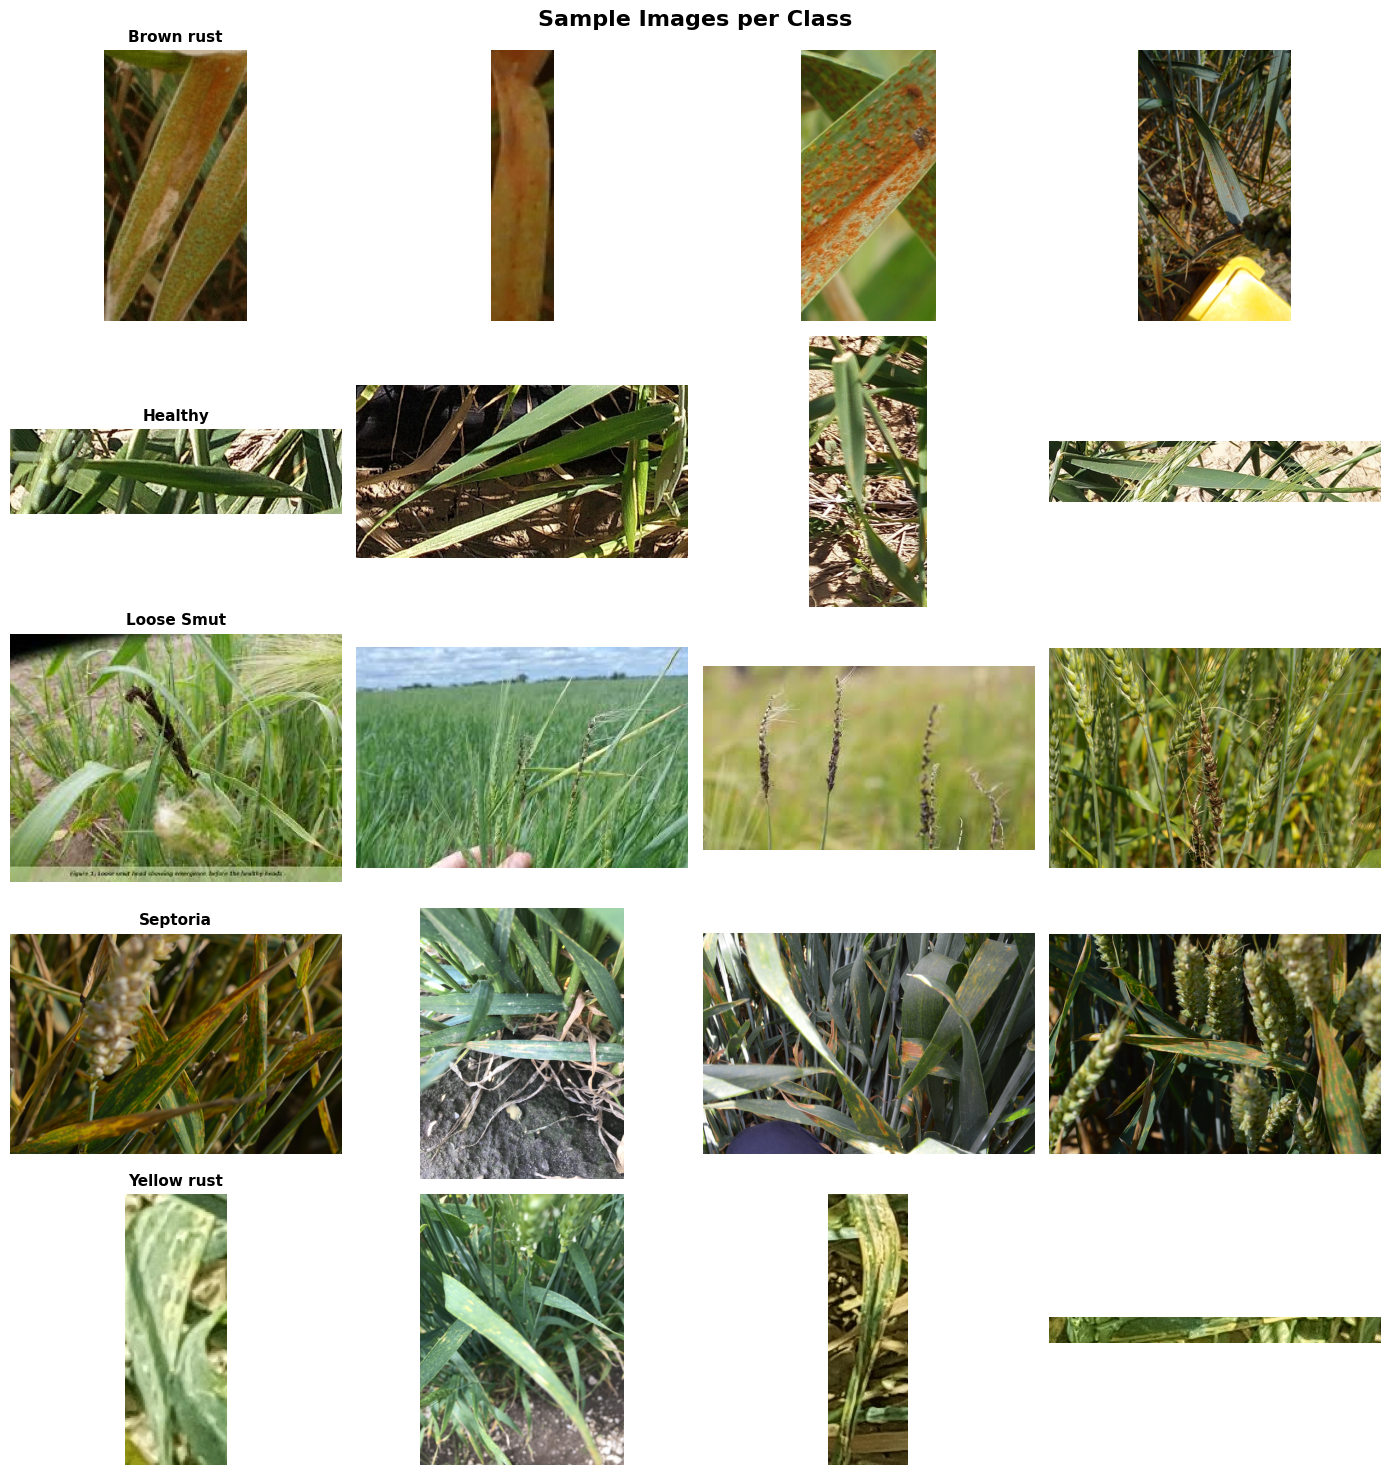

In [10]:
# ─────────────────────────────────────────────────────────────────
#  2.2  Sample Image Viewer
# ─────────────────────────────────────────────────────────────────
cls_list = sorted(os.listdir(CONFIG['data_dir']))
fig, axes = plt.subplots(len(cls_list), 4, figsize=(14, 3 * len(cls_list)))
fig.suptitle('Sample Images per Class', fontsize=16, fontweight='bold')

for row, cls in enumerate(cls_list):
    cls_path = os.path.join(CONFIG['data_dir'], cls)
    imgs = [f for f in os.listdir(cls_path)
            if os.path.isfile(os.path.join(cls_path, f))
            and f.lower().endswith(('.png','.jpg','.jpeg','.bmp','.webp'))][:4]
    for col, img_name in enumerate(imgs):
        img = Image.open(os.path.join(cls_path, img_name)).convert('RGB')
        axes[row, col].imshow(img)
        axes[row, col].set_title(cls if col == 0 else '', fontsize=11, fontweight='bold')
        axes[row, col].axis('off')

plt.tight_layout()
plt.savefig(os.path.join(CONFIG['plots_dir'], 'sample_images.png'), dpi=150)
plt.show()

In [11]:
# ─────────────────────────────────────────────────────────────────
#  2.3  Transforms
# ─────────────────────────────────────────────────────────────────
def get_transforms(img_size, split):
    mean = [0.485, 0.456, 0.406]
    std  = [0.229, 0.224, 0.225]

    if split == 'train':
        return transforms.Compose([
            transforms.Resize((img_size + 32, img_size + 32)),
            transforms.RandomCrop(img_size),
            transforms.RandomHorizontalFlip(),
            transforms.RandomVerticalFlip(),
            transforms.RandomRotation(30),
            transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2, hue=0.1),
            transforms.RandomGrayscale(p=0.05),
            transforms.ToTensor(),
            transforms.Normalize(mean, std),
            transforms.RandomErasing(p=0.1),
        ])

    return transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.ToTensor(),
        transforms.Normalize(mean, std),
    ])

print('✅ Transforms defined')

✅ Transforms defined


In [12]:
# ─────────────────────────────────────────────────────────────────
#  2.4  DataLoader Factory
#  Stratified 70 / 15 / 15 split + weighted sampler for imbalance
# ─────────────────────────────────────────────────────────────────
def get_dataloaders(config, img_size, batch_override=None):
    batch_size = batch_override if batch_override else config['batch_size']
    seed, data_dir = config['seed'], config['data_dir']

    full_ds = datasets.ImageFolder(root=data_dir)
    indices = list(range(len(full_ds)))
    targets = full_ds.targets

    # Stratified split
    train_idx, temp_idx = train_test_split(
        indices, test_size=0.30, stratify=targets, random_state=seed)
    val_idx, test_idx = train_test_split(
        temp_idx, test_size=0.50,
        stratify=[targets[i] for i in temp_idx], random_state=seed)

    def make_subset(idx, split):
        ds = datasets.ImageFolder(root=data_dir,
                                   transform=get_transforms(img_size, split))
        return Subset(ds, idx)

    train_ds = make_subset(train_idx, 'train')
    val_ds   = make_subset(val_idx,   'val')
    test_ds  = make_subset(test_idx,  'test')

    # Class-weighted sampler
    train_labels   = [targets[i] for i in train_idx]
    class_counts   = np.bincount(train_labels, minlength=len(full_ds.classes))
    sample_weights = [1.0 / class_counts[l] for l in train_labels]
    sampler        = WeightedRandomSampler(sample_weights, len(train_idx), replacement=True)

    # Loss weights
    cw = 1.0 / (class_counts + 1e-6)
    class_weights = torch.tensor(cw / cw.sum() * len(full_ds.classes), dtype=torch.float32)

    train_loader = DataLoader(train_ds, batch_size=batch_size, sampler=sampler,
                              num_workers=config['num_workers'], pin_memory=True)
    val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False,
                              num_workers=config['num_workers'], pin_memory=True)
    test_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False,
                              num_workers=config['num_workers'], pin_memory=True)

    return train_loader, val_loader, test_loader, class_weights

print('✅ DataLoader factory defined')

✅ DataLoader factory defined


<a id='section3'></a>
---
## ⚙️ Section 3 — Core Functions

In [13]:
# ─────────────────────────────────────────────────────────────────
#  3.1  Model Builder
#  Attaches a custom 2-layer classification head to any EfficientNet
# ─────────────────────────────────────────────────────────────────
def build_model(model_fn, num_classes, freeze_backbone=True):
    model = model_fn()
    if freeze_backbone:
        for param in model.parameters():
            param.requires_grad = False
    in_features = model.classifier[1].in_features
    model.classifier = nn.Sequential(
        nn.Dropout(p=0.3),
        nn.Linear(in_features, 256),
        nn.ReLU(),
        nn.Dropout(p=0.2),
        nn.Linear(256, num_classes),
    )
    return model

print('✅ build_model defined')

✅ build_model defined


In [14]:
# ─────────────────────────────────────────────────────────────────
#  3.2  Train One Epoch
# ─────────────────────────────────────────────────────────────────
def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for imgs, labels in tqdm(loader, desc='  Train', leave=False):
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        loss = criterion(model(imgs), labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * imgs.size(0)
        correct    += (model(imgs).argmax(1) == labels).sum().item()
        total      += imgs.size(0)
    return total_loss / total, correct / total

# ─────────────────────────────────────────────────────────────────
#  3.3  Evaluate
# ─────────────────────────────────────────────────────────────────
@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []
    for imgs, labels in tqdm(loader, desc='  Eval ', leave=False):
        imgs, labels = imgs.to(device), labels.to(device)
        outputs = model(imgs)
        preds   = outputs.argmax(1)
        total_loss += criterion(outputs, labels).item() * imgs.size(0)
        correct    += (preds == labels).sum().item()
        total      += imgs.size(0)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
    return total_loss / total, correct / total, all_preds, all_labels

# ─────────────────────────────────────────────────────────────────
#  3.4  Get Softmax Probabilities
# ─────────────────────────────────────────────────────────────────
@torch.no_grad()
def get_probs(model, loader):
    model.eval()
    all_probs, all_preds, all_labels = [], [], []
    for imgs, labels in tqdm(loader, desc='  Probs', leave=False):
        out   = model(imgs.to(device))
        probs = F.softmax(out, dim=1).cpu().numpy()
        all_probs.extend(probs)
        all_preds.extend(out.argmax(1).cpu().numpy())
        all_labels.extend(labels.numpy())
    return np.array(all_probs), all_preds, all_labels

print('✅ train_one_epoch / evaluate / get_probs defined')

✅ train_one_epoch / evaluate / get_probs defined


In [15]:
# ─────────────────────────────────────────────────────────────────
#  3.5  Full Training Pipeline  (single model)
#
#  ✅ FIX: checkpoint check happens BEFORE training starts
#          so a saved model is NEVER retrained accidentally
# ─────────────────────────────────────────────────────────────────
def run_model(model_name, config):
    img_size, model_fn, batch_override = MODEL_REGISTRY[model_name]
    set_seed(config['seed'])
    ckpt_path = os.path.join(config['save_dir'], f'best_{model_name}.pth')

    print('=' * 65)
    print(f'🚀  {model_name:<22} | img={img_size} | '
          f'batch={batch_override or config["batch_size"]}')
    print('=' * 65)

    train_loader, val_loader, test_loader, class_weights = \
        get_dataloaders(config, img_size, batch_override)

    model     = build_model(model_fn, config['num_classes'],
                             freeze_backbone=True).to(device)
    criterion = nn.CrossEntropyLoss(weight=class_weights.to(device))
    optimizer = optim.AdamW(model.classifier.parameters(),
                            lr=config['lr'],
                            weight_decay=config['weight_decay'])
    scheduler = CosineAnnealingLR(optimizer, T_max=config['num_epochs'])

    total_p     = sum(p.numel() for p in model.parameters())
    trainable_p = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f'  Params : {total_p/1e6:.1f}M total | {trainable_p/1e6:.2f}M trainable\n')

    history      = {'train_loss':[], 'val_loss':[], 'train_acc':[], 'val_acc':[]}
    best_val_acc = 0.0
    start_time   = time.time()

    for epoch in range(1, config['num_epochs'] + 1):

        # ── Phase 2: unfreeze backbone ───────────────────────────
        if epoch == config['unfreeze_epoch']:
            print(f'  🔓 Epoch {epoch}: Unfreezing backbone...')
            for param in model.parameters():
                param.requires_grad = True
            optimizer.add_param_group({
                'params': model.features.parameters(),
                'lr'    : config['fine_tune_lr']
            })
            scheduler = CosineAnnealingLR(
                optimizer, T_max=config['num_epochs'] - epoch)
            tp = sum(p.numel() for p in model.parameters() if p.requires_grad)
            print(f'  Trainable now: {tp/1e6:.1f}M\n')

        train_loss, train_acc          = train_one_epoch(model, train_loader, criterion, optimizer)
        val_loss,   val_acc,   _, _    = evaluate(model, val_loader, criterion)
        scheduler.step()

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)

        flag = ''
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save({'epoch'      : epoch,
                        'val_acc'    : val_acc,
                        'model_state': model.state_dict()}, ckpt_path)
            flag = '  ✅ Best'

        print(f'  Epoch [{epoch:02d}/{config["num_epochs"]}]  '
              f'Train {train_loss:.4f} / {train_acc:.4f}  |  '
              f'Val {val_loss:.4f} / {val_acc:.4f}{flag}')

    train_time = time.time() - start_time

    # ── Test with best checkpoint ────────────────────────────────
    model.load_state_dict(torch.load(ckpt_path, map_location=device)['model_state'])
    _, test_acc, test_preds, test_labels = evaluate(model, test_loader, criterion)
    f1 = f1_score(test_labels, test_preds, average='weighted')

    print(f'\n  ✅ Done | Test Acc: {test_acc:.4f} | '
          f'F1: {f1:.4f} | Time: {train_time/60:.1f} min\n')
    torch.cuda.empty_cache()

    return {
        'best_val_acc'  : round(best_val_acc * 100, 2),
        'test_acc'      : round(test_acc     * 100, 2),
        'test_f1'       : round(f1           * 100, 2),
        'train_time_min': round(train_time / 60, 1),
        'total_params'  : total_p,
        'img_size'      : img_size,
        'history'       : history,
        'test_preds'    : test_preds,
        'test_labels'   : test_labels,
        'family'        : 'V1' if model_name in V1_MODELS else 'V2',
    }

print('✅ run_model defined')

✅ run_model defined


<a id='section4'></a>
---
## 🏋️ Section 4 — Train All Models

> **Smart skip logic:**
> - ✅ Checkpoint **+** metrics exist → fully skipped
> - 🔄 Checkpoint exists but metrics missing → re-evaluate only (fast, no retraining)
> - 🚀 Neither exists → full training

In [16]:
# ─────────────────────────────────────────────────────────────────
#  4.0  Checkpoint Status Check
#  Run this first to see exactly what's saved and what still needs training.
#  Your V1 models should already show ✅ here.
# ─────────────────────────────────────────────────────────────────
print('=' * 70)
print(f'  CHECKPOINT STATUS — {CONFIG["save_dir"]}')
print('=' * 70)
print(f'  {"Model":<25}  {"Checkpoint":<14}  {"Metrics":<12}  {"Action"}')
print('-' * 70)

needs_training   = []
needs_eval_only  = []
fully_done       = []

for model_name in MODEL_REGISTRY:
    ckpt_path     = os.path.join(CONFIG['save_dir'], f'best_{model_name}.pth')
    ckpt_exists   = os.path.exists(ckpt_path)
    metrics_exist = model_name in all_results

    if ckpt_exists:
        size_mb = os.path.getsize(ckpt_path) / 1024 / 1024
        ckpt_str = f'✅ ({size_mb:.0f} MB)'
    else:
        ckpt_str = '❌ missing'

    metrics_str = '✅ loaded' if metrics_exist else '❌ missing'

    if ckpt_exists and metrics_exist:
        action = '⏭️  skip'
        fully_done.append(model_name)
    elif ckpt_exists and not metrics_exist:
        action = '📊 eval only'
        needs_eval_only.append(model_name)
    else:
        action = '🚀 full train'
        needs_training.append(model_name)

    fam = '(V1)' if model_name in V1_MODELS else '(V2)'
    print(f'  {model_name:<25}  {ckpt_str:<14}  {metrics_str:<12}  {action}  {fam}')

print('=' * 70)
print(f'  ✅ Fully done       : {len(fully_done)} models')
print(f'  📊 Eval only needed : {len(needs_eval_only)} models  {needs_eval_only}')
print(f'  🚀 Training needed  : {len(needs_training)} models  {needs_training}')
print('=' * 70)

  CHECKPOINT STATUS — /home/jupyter-kritika/wheat-project/checkpoints
  Model                      Checkpoint      Metrics       Action
----------------------------------------------------------------------
  EfficientNet-B0            ✅ (17 MB)       ✅ loaded      ⏭️  skip  (V1)
  EfficientNet-B1            ✅ (27 MB)       ✅ loaded      ⏭️  skip  (V1)
  EfficientNet-B2            ✅ (31 MB)       ✅ loaded      ⏭️  skip  (V1)
  EfficientNet-B3            ✅ (43 MB)       ✅ loaded      ⏭️  skip  (V1)
  EfficientNet-B4            ✅ (69 MB)       ✅ loaded      ⏭️  skip  (V1)
  EfficientNet-B5            ✅ (111 MB)      ✅ loaded      ⏭️  skip  (V1)
  EfficientNet-B6            ✅ (159 MB)      ✅ loaded      ⏭️  skip  (V1)
  EfficientNet-B7            ✅ (247 MB)      ✅ loaded      ⏭️  skip  (V1)
  EfficientNet-V2-B0         ✅ (79 MB)       ✅ loaded      ⏭️  skip  (V2)
  EfficientNet-V2-B1         ✅ (79 MB)       ✅ loaded      ⏭️  skip  (V2)
  EfficientNet-V2-B2         ✅ (79 MB)       ✅ loaded

In [17]:
from tqdm import tqdm

In [18]:
# ─────────────────────────────────────────────────────────────────
#  4.1  Training Loop  —  checkpoint-aware, auto-saves after every model
# ─────────────────────────────────────────────────────────────────
for model_name in MODEL_REGISTRY:
    ckpt_path = os.path.join(CONFIG['save_dir'], f'best_{model_name}.pth')
    ckpt_exists    = os.path.exists(ckpt_path)
    metrics_exist  = model_name in all_results

    if ckpt_exists and metrics_exist:
        print(f'⏭️  {model_name:<25} — checkpoint + metrics exist, skipping')
        continue

    if ckpt_exists and not metrics_exist:
        print(f'📊 {model_name:<25} — checkpoint found, re-evaluating only...')
        # Load checkpoint and evaluate on test set without retraining
        img_size, model_fn, batch_override = MODEL_REGISTRY[model_name]
        _, _, test_loader, class_weights   = get_dataloaders(CONFIG, img_size, batch_override)
        model = build_model(model_fn, CONFIG['num_classes'],
                             freeze_backbone=False).to(device)
        model.load_state_dict(
            torch.load(ckpt_path, map_location=device)['model_state'])
        criterion = nn.CrossEntropyLoss(weight=class_weights.to(device))
        _, test_acc, test_preds, test_labels = evaluate(model, test_loader, criterion)
        f1 = f1_score(test_labels, test_preds, average='weighted')
        torch.cuda.empty_cache()
        all_results[model_name] = {
            'best_val_acc': None, 'test_acc': round(test_acc*100,2),
            'test_f1': round(f1*100,2), 'train_time_min': None,
            'total_params': sum(p.numel() for p in model.parameters()),
            'img_size': img_size, 'history': None,
            'test_preds': test_preds, 'test_labels': test_labels,
            'family': 'V1' if model_name in V1_MODELS else 'V2',
        }
    else:
        # Full training
        all_results[model_name] = run_model(model_name, CONFIG)

    # Auto-save after every model so progress is never lost
    save_json(all_results, RESULTS_FILE)
    print(f'  💾 Results saved ({len(all_results)}/{len(MODEL_REGISTRY)} models done)\n')

print('\n🏁 All models complete!')

⏭️  EfficientNet-B0           — checkpoint + metrics exist, skipping
⏭️  EfficientNet-B1           — checkpoint + metrics exist, skipping
⏭️  EfficientNet-B2           — checkpoint + metrics exist, skipping
⏭️  EfficientNet-B3           — checkpoint + metrics exist, skipping
⏭️  EfficientNet-B4           — checkpoint + metrics exist, skipping
⏭️  EfficientNet-B5           — checkpoint + metrics exist, skipping
⏭️  EfficientNet-B6           — checkpoint + metrics exist, skipping
⏭️  EfficientNet-B7           — checkpoint + metrics exist, skipping
⏭️  EfficientNet-V2-B0        — checkpoint + metrics exist, skipping
⏭️  EfficientNet-V2-B1        — checkpoint + metrics exist, skipping
⏭️  EfficientNet-V2-B2        — checkpoint + metrics exist, skipping
⏭️  EfficientNet-V2-B3        — checkpoint + metrics exist, skipping
⏭️  EfficientNet-V2-S         — checkpoint + metrics exist, skipping
⏭️  EfficientNet-V2-M         — checkpoint + metrics exist, skipping
⏭️  EfficientNet-V2-L         — ch

<a id='section5'></a>
---
## 📊 Section 5 — Metrics Computation
> Loads each best checkpoint and computes accuracy, F1, MCC, Kappa, ROC-AUC.  
> Already-computed models are skipped.

In [19]:
# ─────────────────────────────────────────────────────────────────
#  5.1  Full Metrics Helper
# ─────────────────────────────────────────────────────────────────
def compute_full_metrics(labels, preds, probs, classes):
    n          = len(classes)
    labels_bin = label_binarize(labels, classes=list(range(n)))
    probs      = np.array(probs).reshape(-1, n)

    try:
        roc_auc = roc_auc_score(labels_bin, probs, multi_class='ovr', average='macro')
    except Exception:
        roc_auc = float('nan')

    cm = confusion_matrix(labels, preds)

    return {
        'overall_acc'   : round(accuracy_score(labels, preds)                        * 100, 2),
        'balanced_acc'  : round(balanced_accuracy_score(labels, preds)               * 100, 2),
        'macro_f1'      : round(f1_score(labels, preds, average='macro')             * 100, 2),
        'weighted_f1'   : round(f1_score(labels, preds, average='weighted')          * 100, 2),
        'micro_f1'      : round(f1_score(labels, preds, average='micro')             * 100, 2),
        'macro_prec'    : round(precision_score(labels, preds, average='macro',    zero_division=0) * 100, 2),
        'weighted_prec' : round(precision_score(labels, preds, average='weighted', zero_division=0) * 100, 2),
        'macro_rec'     : round(recall_score(labels, preds,    average='macro',    zero_division=0) * 100, 2),
        'weighted_rec'  : round(recall_score(labels, preds,    average='weighted', zero_division=0) * 100, 2),
        'mcc'           : round(matthews_corrcoef(labels, preds), 4),
        'kappa'         : round(cohen_kappa_score(labels, preds), 4),
        'roc_auc'       : round(roc_auc, 4) if not np.isnan(roc_auc) else None,
        'per_class_acc' : {c: round(v, 2) for c, v in
                           zip(classes, cm.diagonal() / cm.sum(axis=1) * 100)},
        'per_class_prec': {c: round(v, 2) for c, v in
                           zip(classes, precision_score(labels, preds, average=None, zero_division=0) * 100)},
        'per_class_rec' : {c: round(v, 2) for c, v in
                           zip(classes, recall_score(labels, preds,    average=None, zero_division=0) * 100)},
        'per_class_f1'  : {c: round(v, 2) for c, v in
                           zip(classes, f1_score(labels, preds,        average=None, zero_division=0) * 100)},
        'confusion_matrix': cm.tolist(),
    }

print('✅ compute_full_metrics defined')

✅ compute_full_metrics defined


In [20]:
# ─────────────────────────────────────────────────────────────────
#  5.2  Compute metrics for all models  (skips already-done)
# ─────────────────────────────────────────────────────────────────
for model_name, res in all_results.items():
    if model_name in full_metrics:
        print(f'⏭️  {model_name:<25} — metrics already computed')
        continue

    print(f'📊 Computing full metrics for {model_name}...')
    img_size, model_fn, batch_override = MODEL_REGISTRY[model_name]
    _, _, test_loader, class_weights   = get_dataloaders(CONFIG, img_size, batch_override)

    model = build_model(model_fn, CONFIG['num_classes'],
                         freeze_backbone=False).to(device)
    model.load_state_dict(
        torch.load(os.path.join(CONFIG['save_dir'], f'best_{model_name}.pth'),
                   map_location=device)['model_state'])

    probs, preds, labels = get_probs(model, test_loader)
    metrics = compute_full_metrics(labels, preds, probs, CLASSES)
    torch.cuda.empty_cache()

    full_metrics[model_name] = {
        **metrics,
        'family'        : res['family'],
        'params_M'      : round(res['total_params'] / 1e6, 1),
        'img_size'      : img_size,
        'train_time_min': res.get('train_time_min'),
    }

    # Save after every model
    save_json(full_metrics, FULL_METRICS_FILE)
    print(f'  ✅ OvAcc={metrics["overall_acc"]}% | '
          f'BalAcc={metrics["balanced_acc"]}% | '
          f'MacroF1={metrics["macro_f1"]}% | MCC={metrics["mcc"]}\n')

print('\n✅ All metrics computed and saved!')

⏭️  EfficientNet-B0           — metrics already computed
⏭️  EfficientNet-B1           — metrics already computed
⏭️  EfficientNet-B2           — metrics already computed
⏭️  EfficientNet-B3           — metrics already computed
⏭️  EfficientNet-B4           — metrics already computed
⏭️  EfficientNet-B5           — metrics already computed
⏭️  EfficientNet-B6           — metrics already computed
⏭️  EfficientNet-B7           — metrics already computed
⏭️  EfficientNet-V2-B0        — metrics already computed
⏭️  EfficientNet-V2-B1        — metrics already computed
⏭️  EfficientNet-V2-B2        — metrics already computed
⏭️  EfficientNet-V2-B3        — metrics already computed
⏭️  EfficientNet-V2-S         — metrics already computed
⏭️  EfficientNet-V2-M         — metrics already computed
⏭️  EfficientNet-V2-L         — metrics already computed

✅ All metrics computed and saved!


<a id='section6'></a>
---
## 📋 Section 6 — Results Tables

In [21]:
# ─────────────────────────────────────────────────────────────────
#  6.1  Master Comparison Table
# ─────────────────────────────────────────────────────────────────
rows = []
for name, m in full_metrics.items():
    rows.append({
        'Model'            : name,
        'Family'           : m['family'],
        'Params (M)'       : m['params_M'],
        'Overall Acc (%)'  : m['overall_acc'],
        'Balanced Acc (%)'  : m['balanced_acc'],
        'Macro F1 (%)'     : m['macro_f1'],
        'Weighted F1 (%)'  : m['weighted_f1'],
        'Macro Prec (%)'   : m['macro_prec'],
        'Macro Recall (%)' : m['macro_rec'],
        'MCC'              : m['mcc'],
        'Kappa'            : m['kappa'],
        'ROC-AUC'          : m['roc_auc'],
        'Train (min)'      : m['train_time_min'],
    })

df_master = (pd.DataFrame(rows)
               .sort_values('Balanced Acc (%)', ascending=False)
               .reset_index(drop=True))
df_master.index += 1

styled = (df_master.style
    .background_gradient(cmap='YlGn',
        subset=['Overall Acc (%)','Balanced Acc (%)','Macro F1 (%)','Weighted F1 (%)','ROC-AUC'])
    .background_gradient(cmap='Blues', subset=['MCC','Kappa'])
    .highlight_max(
        subset=['Overall Acc (%)','Balanced Acc (%)','Macro F1 (%)','MCC','Kappa','ROC-AUC'],
        color='#d4edda')
    .format({
        'Overall Acc (%)'  : '{:.2f}', 'Balanced Acc (%)' : '{:.2f}',
        'Macro F1 (%)'     : '{:.2f}', 'Weighted F1 (%)'  : '{:.2f}',
        'Macro Prec (%)'   : '{:.2f}', 'Macro Recall (%)' : '{:.2f}',
        'MCC'              : '{:.4f}', 'Kappa'            : '{:.4f}',
        'ROC-AUC'          : '{:.4f}', 'Params (M)'       : '{:.1f}',
    })
    .set_caption('📊 Full Metrics — sorted by Balanced Accuracy · Green = best per column'))

display(styled)
df_master.to_csv(os.path.join(CONFIG['results_dir'], 'master_comparison.csv'))
print(f'\n🥇 Best Balanced Acc : {df_master.iloc[0]["Model"]} — {df_master.iloc[0]["Balanced Acc (%)"]}%')
print(f'🥇 Best Macro F1     : {df_master.sort_values("Macro F1 (%)",ascending=False).iloc[0]["Model"]} — {df_master["Macro F1 (%)"].max()}%')

,Model,Family,Params (M),Overall Acc (%),Balanced Acc (%),Macro F1 (%),Weighted F1 (%),Macro Prec (%),Macro Recall (%),MCC,Kappa,ROC-AUC,Train (min)
1,EfficientNet-B5,V1,28.9,98.31,98.65,97.82,98.32,97.11,98.65,0.9782,0.9781,0.9993,nan
2,EfficientNet-V2-L,V2,117.6,98.91,98.18,98.65,98.91,99.17,98.18,0.9859,0.9859,0.9998,28.300000
3,EfficientNet-V2-M,V2,53.2,98.43,98.17,98.05,98.43,97.93,98.17,0.9796,0.9796,0.9996,nan
4,EfficientNet-B7,V1,64.4,98.67,98.12,97.98,98.68,97.84,98.12,0.9828,0.9828,0.9996,79.800000
5,EfficientNet-V2-B3,V2,20.5,97.35,97.92,96.32,97.41,95.16,97.92,0.9659,0.9656,0.9990,8.300000
6,EfficientNet-V2-S,V2,20.5,98.31,97.82,97.57,98.32,97.34,97.82,0.9781,0.9781,0.9994,11.400000
7,EfficientNet-B3,V1,11.1,97.35,97.55,96.51,97.37,95.67,97.55,0.9657,0.9656,0.9992,nan
8,EfficientNet-B2,V1,8.1,96.86,97.48,96.54,96.87,95.75,97.48,0.9594,0.9593,0.9984,nan
9,EfficientNet-B1,V1,6.8,97.23,97.18,96.79,97.23,96.43,97.18,0.9640,0.9640,0.9975,nan
10,EfficientNet-V2-B2,V2,20.5,96.86,97.17,95.95,96.91,95.00,97.17,0.9595,0.9593,0.9988,6.700000



🥇 Best Balanced Acc : EfficientNet-B5 — 98.65%
🥇 Best Macro F1     : EfficientNet-V2-L — 98.65%


In [22]:
# ─────────────────────────────────────────────────────────────────
#  6.2  Per-Class Metrics Table
# ─────────────────────────────────────────────────────────────────
per_class_rows = []
for name, m in full_metrics.items():
    row = {'Model': name, 'Family': m['family']}
    for cls in CLASSES:
        row[f'{cls} | Acc']  = m['per_class_acc'][cls]
        row[f'{cls} | Prec'] = m['per_class_prec'][cls]
        row[f'{cls} | Rec']  = m['per_class_rec'][cls]
        row[f'{cls} | F1']   = m['per_class_f1'][cls]
    per_class_rows.append(row)

df_per_class = (pd.DataFrame(per_class_rows)
                  .sort_values('Model')
                  .set_index(['Model','Family']))

fmt_dict = {col: '{:.1f}' for col in df_per_class.columns}
display(
    df_per_class.style
    .background_gradient(cmap='RdYlGn', axis=0)
    .format(fmt_dict)
    .set_caption('🌿 Per-Class Accuracy / Precision / Recall / F1 (%) — All Models')
)

,,Brown rust | Acc,Brown rust | Prec,Brown rust | Rec,Brown rust | F1,Healthy | Acc,Healthy | Prec,Healthy | Rec,Healthy | F1,Loose Smut | Acc,Loose Smut | Prec,Loose Smut | Rec,Loose Smut | F1,Septoria | Acc,Septoria | Prec,Septoria | Rec,Septoria | F1,Yellow rust | Acc,Yellow rust | Prec,Yellow rust | Rec,Yellow rust | F1
Model,Family,,,,,,,,,,,,,,,,,,,,
EfficientNet-B0,V1,97.3,98.4,97.3,97.9,98.3,99.6,98.3,99.0,99.3,100.0,99.3,99.6,94.3,80.7,94.3,87.0,94.7,96.1,94.7,95.4
EfficientNet-B1,V1,94.7,97.3,94.7,96.0,98.3,98.3,98.3,98.3,100.0,99.3,100.0,99.6,96.2,91.1,96.2,93.6,96.7,96.2,96.7,96.4
EfficientNet-B2,V1,95.2,96.8,95.2,96.0,97.9,98.7,97.9,98.3,100.0,99.3,100.0,99.6,100.0,88.3,100.0,93.8,94.3,95.6,94.3,94.9
EfficientNet-B3,V1,97.3,97.3,97.3,97.3,98.7,99.2,98.7,99.0,99.3,98.6,99.3,98.9,98.1,85.2,98.1,91.2,94.3,98.0,94.3,96.1
EfficientNet-B4,V1,97.3,97.3,97.3,97.3,97.5,99.2,97.5,98.3,100.0,98.6,100.0,99.3,96.2,86.4,96.2,91.1,93.8,95.6,93.8,94.7
EfficientNet-B5,V1,98.4,97.9,98.4,98.2,99.2,100.0,99.2,99.6,100.0,99.3,100.0,99.6,100.0,89.8,100.0,94.6,95.7,98.5,95.7,97.1
EfficientNet-B6,V1,98.4,94.9,98.4,96.6,98.3,99.2,98.3,98.7,98.6,99.3,98.6,98.9,94.3,89.3,94.3,91.7,94.7,98.0,94.7,96.3
EfficientNet-B7,V1,99.5,99.0,99.5,99.2,99.2,99.6,99.2,99.4,100.0,100.0,100.0,100.0,94.3,92.6,94.3,93.5,97.6,98.1,97.6,97.8
EfficientNet-V2-B0,V2,92.1,95.1,92.1,93.5,92.0,98.7,92.0,95.2,97.1,96.4,97.1,96.8,100.0,59.5,100.0,74.7,87.6,94.3,87.6,90.8


<a id='section7'></a>
---
## 📈 Section 7 — Visualizations
> All plots are saved to `./plots/` automatically.

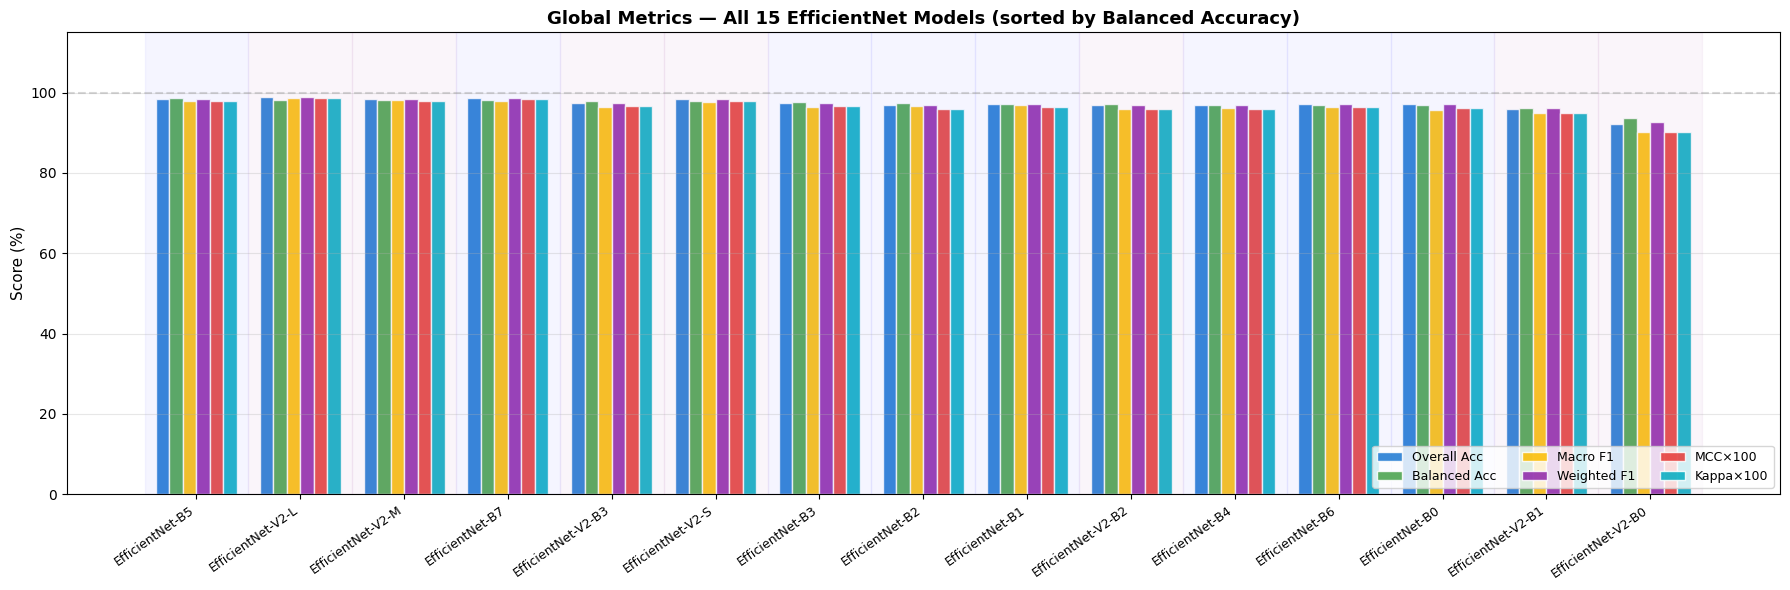

In [23]:
# ─────────────────────────────────────────────────────────────────
#  7.1  Global Metrics Bar Chart
# ─────────────────────────────────────────────────────────────────
sorted_models   = df_master['Model'].tolist()
metrics_to_plot = {
    'Overall Acc'  : [full_metrics[m]['overall_acc']  for m in sorted_models],
    'Balanced Acc' : [full_metrics[m]['balanced_acc'] for m in sorted_models],
    'Macro F1'     : [full_metrics[m]['macro_f1']     for m in sorted_models],
    'Weighted F1'  : [full_metrics[m]['weighted_f1']  for m in sorted_models],
    'MCC×100'      : [full_metrics[m]['mcc']*100      for m in sorted_models],
    'Kappa×100'    : [full_metrics[m]['kappa']*100    for m in sorted_models],
}
colors  = ['#1976D2','#43A047','#FBBC00','#8E24AA','#E53935','#00ACC1']
x, n    = np.arange(len(sorted_models)), len(metrics_to_plot)
width   = 0.13
offsets = np.linspace(-(n-1)*width/2, (n-1)*width/2, n)

fig, ax = plt.subplots(figsize=(18, 6))
for (label, vals), offset, color in zip(metrics_to_plot.items(), offsets, colors):
    ax.bar(x + offset, vals, width, label=label, color=color, alpha=0.85, edgecolor='white')
ax.set_xticks(x)
ax.set_xticklabels(sorted_models, rotation=35, ha='right', fontsize=9)
ax.set_ylabel('Score (%)', fontsize=11)
ax.set_title('Global Metrics — All 15 EfficientNet Models (sorted by Balanced Accuracy)',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=9, loc='lower right', ncol=3)
ax.set_ylim(0, 115); ax.grid(axis='y', alpha=0.3)
ax.axhline(100, color='gray', linestyle='--', alpha=0.3)
for i, m in enumerate(sorted_models):
    ax.axvspan(i-0.5, i+0.5, alpha=0.04,
               color='blue' if full_metrics[m]['family']=='V1' else 'purple')
plt.tight_layout()
plt.savefig(os.path.join(CONFIG['plots_dir'], 'global_metrics_bar.png'), dpi=150)
plt.show()

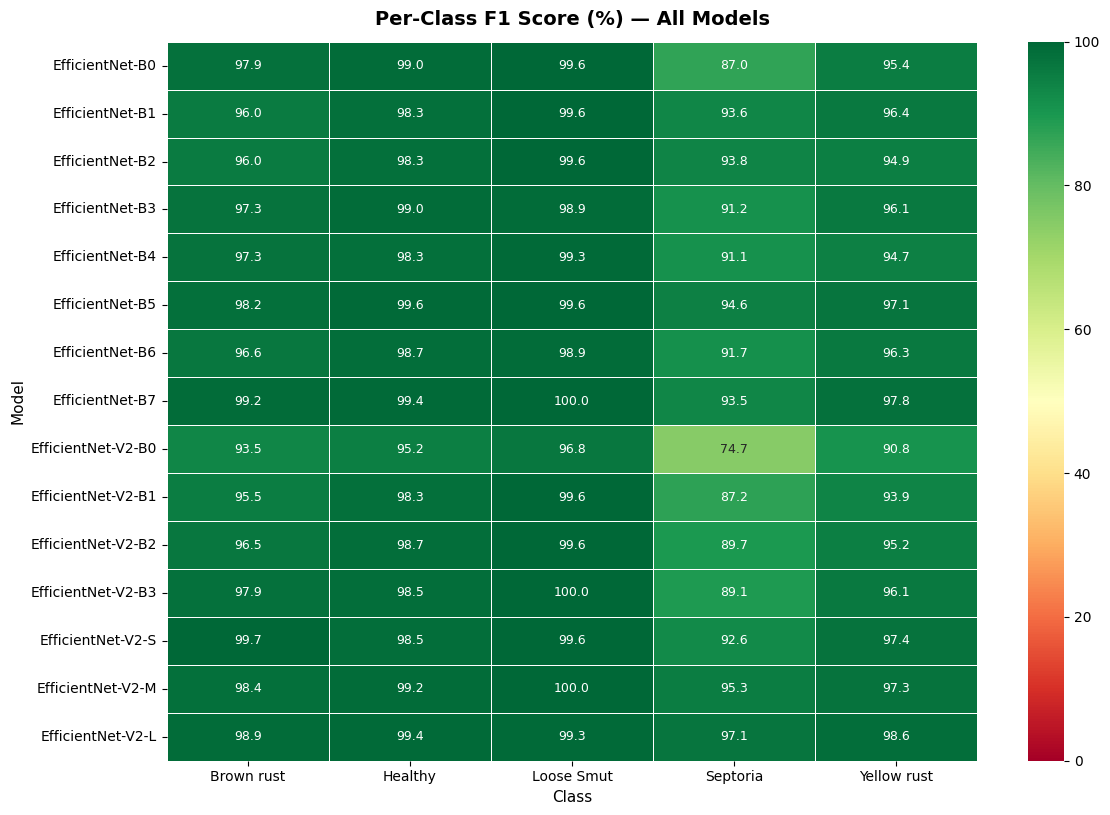

In [24]:
# ─────────────────────────────────────────────────────────────────
#  7.2  Per-Class F1 Heatmap
# ─────────────────────────────────────────────────────────────────
model_names = list(full_metrics.keys())
f1_matrix   = np.array([[full_metrics[m]['per_class_f1'][c]
                          for c in CLASSES] for m in model_names])

fig, ax = plt.subplots(figsize=(12, max(8, len(model_names)*0.55)))
sns.heatmap(f1_matrix, annot=True, fmt='.1f', cmap='RdYlGn',
            xticklabels=CLASSES, yticklabels=model_names,
            linewidths=0.4, vmin=0, vmax=100, ax=ax,
            annot_kws={'size': 9})
ax.set_title('Per-Class F1 Score (%) — All Models',
             fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Class', fontsize=11); ax.set_ylabel('Model', fontsize=11)
plt.tight_layout()
plt.savefig(os.path.join(CONFIG['plots_dir'], 'per_class_f1_heatmap.png'), dpi=150)
plt.show()

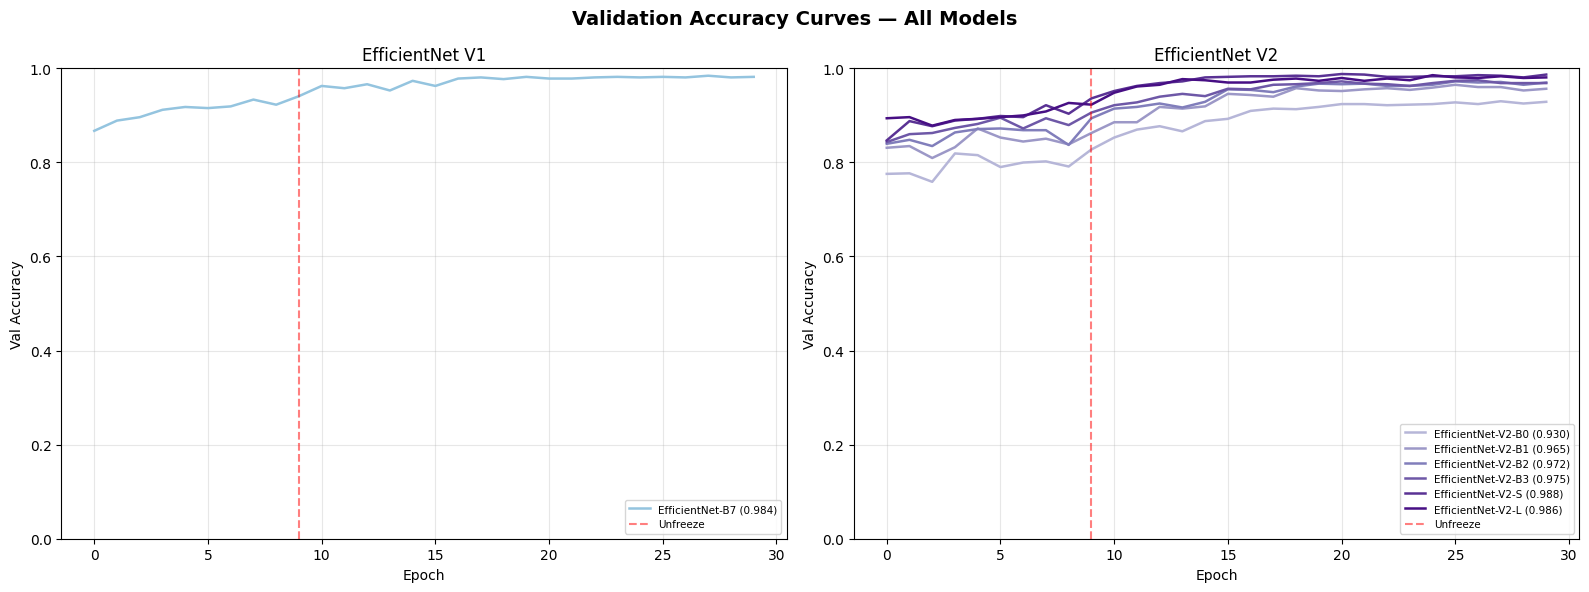

In [25]:
# ─────────────────────────────────────────────────────────────────
#  7.3  Validation Accuracy Curves (V1 & V2 side-by-side)
# ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Validation Accuracy Curves — All Models',
             fontsize=14, fontweight='bold')

for ax, family, models_list, cmap_name in [
    (axes[0], 'V1', V1_MODELS, 'Blues'),
    (axes[1], 'V2', V2_MODELS, 'Purples'),
]:
    available = [m for m in models_list
                 if m in all_results and all_results[m].get('history')]
    colors_c  = plt.get_cmap(cmap_name)(np.linspace(0.4, 0.95, len(available)))
    for name, color in zip(available, colors_c):
        hist = all_results[name]['history']
        best = max(hist['val_acc'])
        ax.plot(hist['val_acc'], label=f'{name} ({best:.3f})',
                color=color, linewidth=1.8)
    ax.axvline(CONFIG['unfreeze_epoch'] - 1, color='red', linestyle='--',
               alpha=0.5, label='Unfreeze')
    ax.set_title(f'EfficientNet {family}')
    ax.set_xlabel('Epoch'); ax.set_ylabel('Val Accuracy')
    ax.set_ylim(0, 1); ax.grid(alpha=0.3)
    ax.legend(fontsize=7.5, loc='lower right')

plt.tight_layout()
plt.savefig(os.path.join(CONFIG['plots_dir'], 'val_curves.png'), dpi=150)
plt.show()

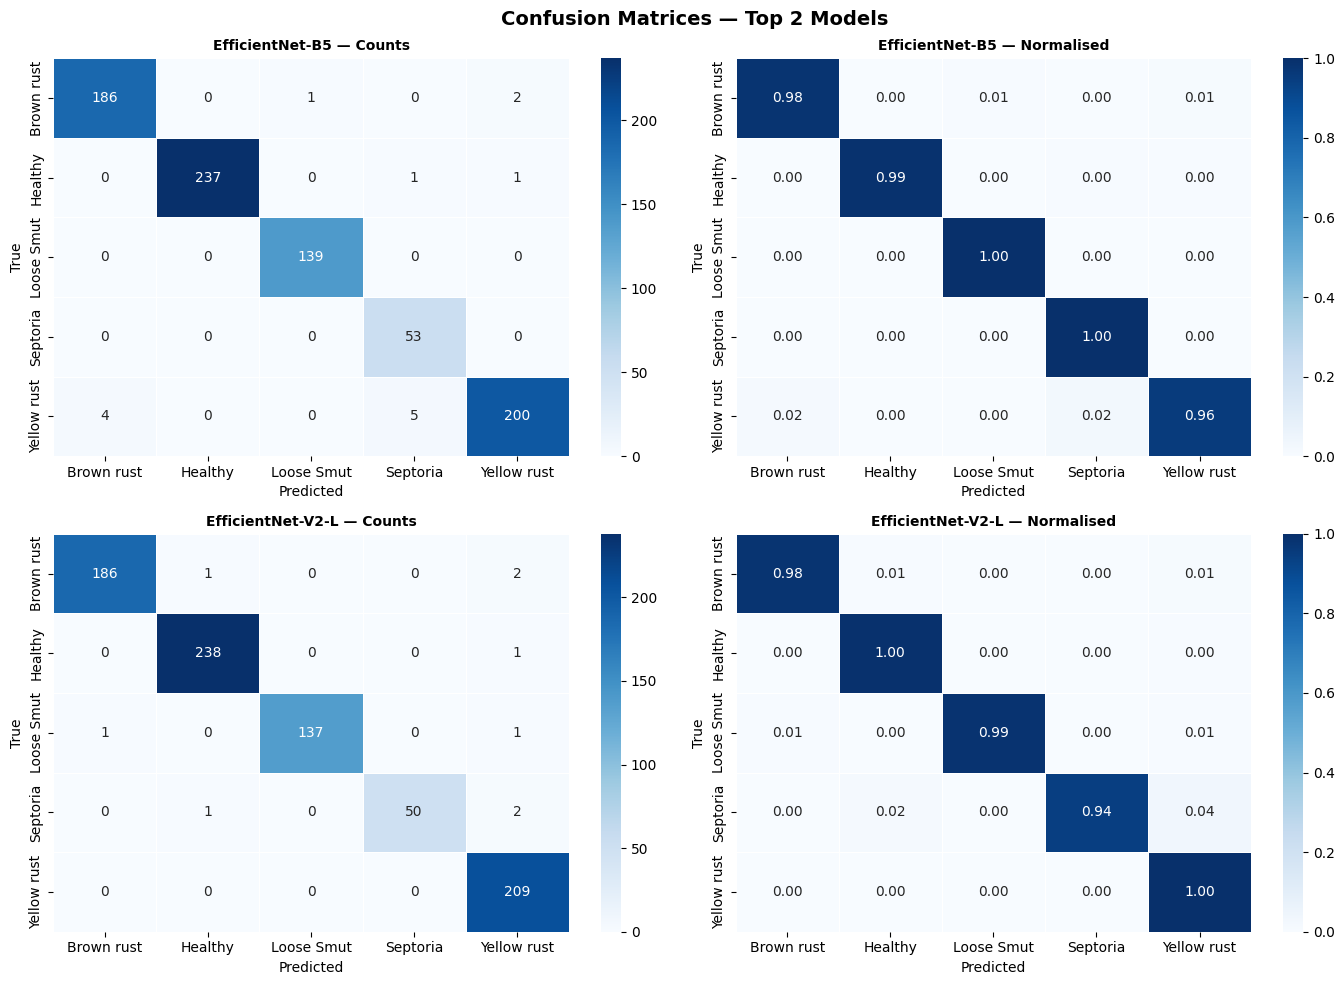

In [26]:
# ─────────────────────────────────────────────────────────────────
#  7.4  Confusion Matrices — Top 2 Models
# ─────────────────────────────────────────────────────────────────
top2  = df_master.head(2)['Model'].tolist()
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Confusion Matrices — Top 2 Models',
             fontsize=14, fontweight='bold')

for row_idx, name in enumerate(top2):
    cm_raw = np.array(full_metrics[name]['confusion_matrix'])
    cm_n   = cm_raw.astype(float) / cm_raw.sum(axis=1, keepdims=True)
    for col_idx, (data, fmt, title) in enumerate([
        (cm_raw, 'd',   f'{name} — Counts'),
        (cm_n,   '.2f', f'{name} — Normalised'),
    ]):
        ax = axes[row_idx][col_idx]
        sns.heatmap(data, annot=True, fmt=fmt, cmap='Blues',
                    xticklabels=CLASSES, yticklabels=CLASSES,
                    linewidths=0.4, ax=ax)
        ax.set_title(title, fontsize=10, fontweight='bold')
        ax.set_xlabel('Predicted'); ax.set_ylabel('True')

plt.tight_layout()
plt.savefig(os.path.join(CONFIG['plots_dir'], 'confusion_matrices_top2.png'), dpi=150)
plt.show()

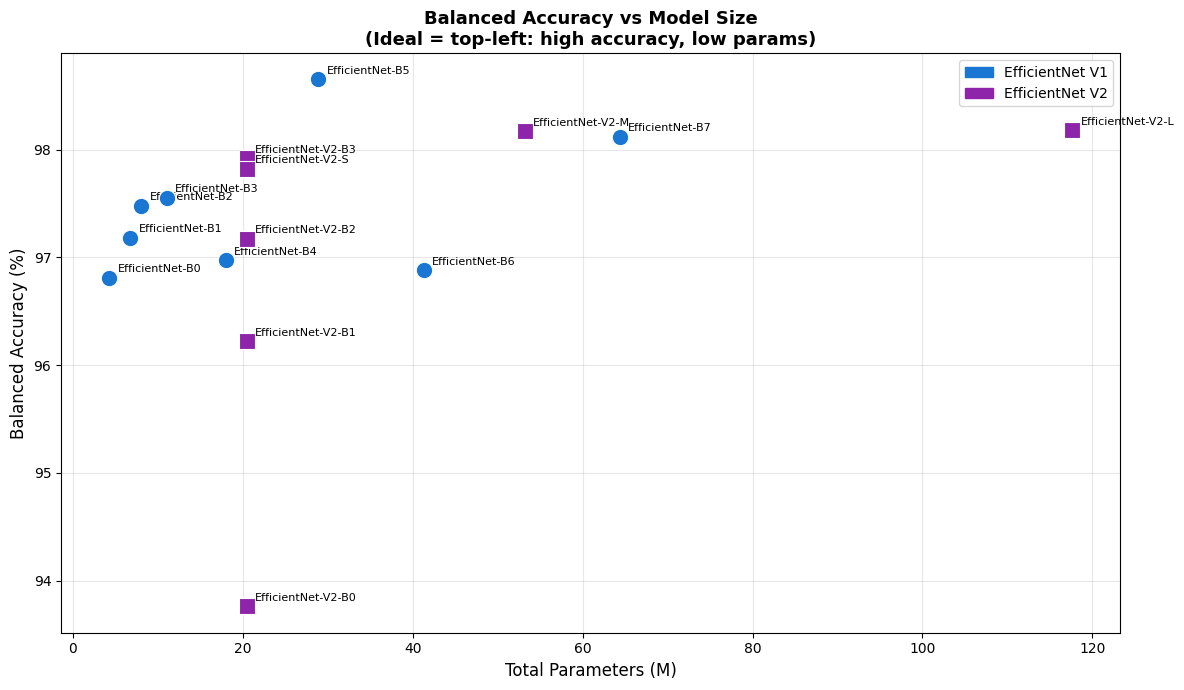

In [27]:
# ─────────────────────────────────────────────────────────────────
#  7.5  Balanced Accuracy vs Model Size Scatter
# ─────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 7))
for name, m in full_metrics.items():
    color  = '#1976D2' if m['family']=='V1' else '#8E24AA'
    marker = 'o'       if m['family']=='V1' else 's'
    ax.scatter(m['params_M'], m['balanced_acc'], s=140,
               color=color, marker=marker, edgecolors='white',
               linewidths=0.8, zorder=3)
    ax.annotate(name, (m['params_M'], m['balanced_acc']),
                textcoords='offset points', xytext=(6, 4), fontsize=8)
ax.set_xlabel('Total Parameters (M)', fontsize=12)
ax.set_ylabel('Balanced Accuracy (%)', fontsize=12)
ax.set_title('Balanced Accuracy vs Model Size\n(Ideal = top-left: high accuracy, low params)',
             fontsize=13, fontweight='bold')
ax.grid(alpha=0.3)
ax.legend(handles=[
    mpatches.Patch(color='#1976D2', label='EfficientNet V1'),
    mpatches.Patch(color='#8E24AA', label='EfficientNet V2'),
], fontsize=10)
plt.tight_layout()
plt.savefig(os.path.join(CONFIG['plots_dir'], 'balanced_acc_vs_params.png'), dpi=150)
plt.show()

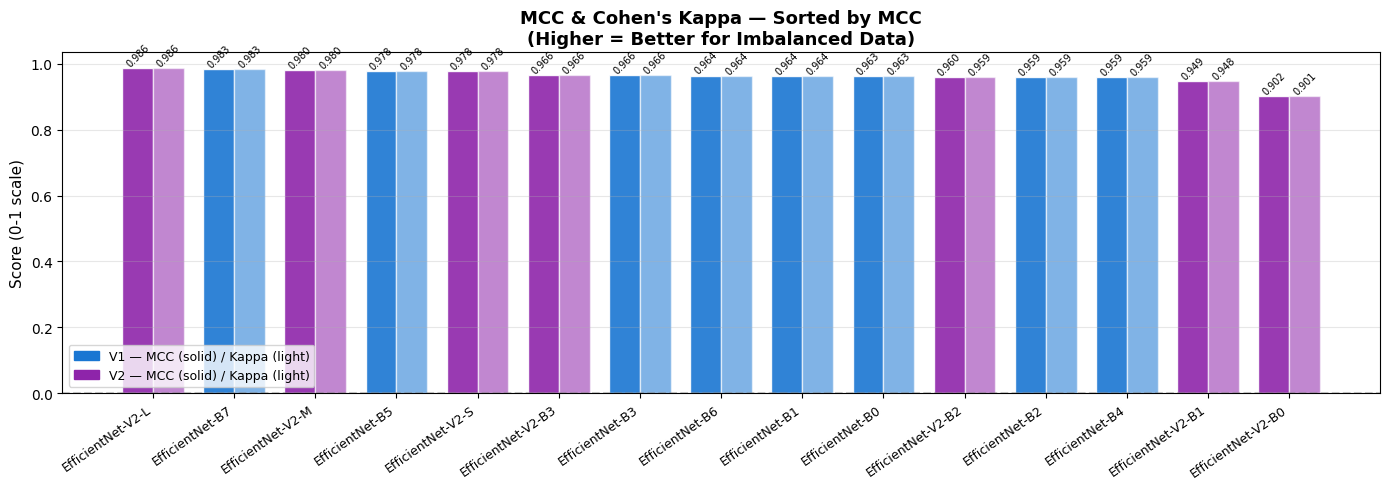

In [28]:
# ─────────────────────────────────────────────────────────────────
#  7.6  MCC & Cohen's Kappa Bar Chart
# ─────────────────────────────────────────────────────────────────
sorted_by_mcc = sorted(full_metrics.keys(),
                        key=lambda m: full_metrics[m]['mcc'], reverse=True)
mcc_vals   = [full_metrics[m]['mcc']   for m in sorted_by_mcc]
kappa_vals = [full_metrics[m]['kappa'] for m in sorted_by_mcc]
fam_colors = ['#1976D2' if full_metrics[m]['family']=='V1' else '#8E24AA'
               for m in sorted_by_mcc]

x, width = np.arange(len(sorted_by_mcc)), 0.38
fig, ax = plt.subplots(figsize=(14, 5))
b1 = ax.bar(x - width/2, mcc_vals,   width, label='MCC',          color=fam_colors, edgecolor='white', alpha=0.9)
b2 = ax.bar(x + width/2, kappa_vals, width, label="Cohen's Kappa", color=fam_colors, edgecolor='white', alpha=0.55)
for bar in list(b1) + list(b2):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
            f'{bar.get_height():.3f}', ha='center', fontsize=7, rotation=45)
ax.set_xticks(x)
ax.set_xticklabels(sorted_by_mcc, rotation=35, ha='right', fontsize=9)
ax.set_ylabel('Score (0-1 scale)', fontsize=11)
ax.set_title('MCC & Cohen\'s Kappa — Sorted by MCC\n(Higher = Better for Imbalanced Data)',
             fontsize=13, fontweight='bold')
ax.axhline(0, color='gray', linestyle='--', alpha=0.4)
ax.grid(axis='y', alpha=0.3)
ax.legend(handles=[
    mpatches.Patch(color='#1976D2', label='V1 — MCC (solid) / Kappa (light)'),
    mpatches.Patch(color='#8E24AA', label='V2 — MCC (solid) / Kappa (light)'),
], fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(CONFIG['plots_dir'], 'mcc_kappa.png'), dpi=150)
plt.show()

<a id='section8'></a>
---
## 🏆 Section 8 — Final Verdict

In [29]:
# ─────────────────────────────────────────────────────────────────
#  8.1  Best Model Per Metric
# ─────────────────────────────────────────────────────────────────
print('=' * 65)
print('🏆  FINAL VERDICT — Best Model per Metric')
print('=' * 65)

metric_cols = {
    'Overall Accuracy'  : 'overall_acc',
    'Balanced Accuracy' : 'balanced_acc',
    'Macro F1'          : 'macro_f1',
    'Weighted F1'       : 'weighted_f1',
    'Macro Precision'   : 'macro_prec',
    'Macro Recall'      : 'macro_rec',
    'MCC'               : 'mcc',
    'Cohen Kappa'       : 'kappa',
    'ROC-AUC'           : 'roc_auc',
}

verdict_rows = []
for label, key in metric_cols.items():
    best_name = max(full_metrics, key=lambda m: full_metrics[m][key] or 0)
    best_val  = full_metrics[best_name][key]
    unit = '%' if key not in ('mcc','kappa','roc_auc') else ''
    verdict_rows.append({
        'Metric'     : label,
        'Best Model' : best_name,
        'Score'      : f'{best_val:.4f}{unit}',
        'Family'     : full_metrics[best_name]['family'],
    })

df_verdict = pd.DataFrame(verdict_rows)

wins = df_verdict['Best Model'].value_counts()
print('\n🏅 Win count per model:')
for model, count in wins.items():
    fam = full_metrics[model]['family']
    print(f'   {model:<28} [{fam}]  →  {count} metric(s)')

display(
    df_verdict.style
    .apply(lambda x: ['background-color:#d4edda' if x['Family']=='V2'
                       else 'background-color:#dbeafe'
                       for _ in x], axis=1)
    .set_caption('🏆 Best Model per Metric  |  🟢 V2  🔵 V1')
)

# Save final verdict
df_verdict.to_csv(os.path.join(CONFIG['results_dir'], 'final_verdict.csv'), index=False)
print('\n💾 Final verdict saved!')

🏆  FINAL VERDICT — Best Model per Metric

🏅 Win count per model:
   EfficientNet-V2-L            [V2]  →  7 metric(s)
   EfficientNet-B5              [V1]  →  2 metric(s)


,Metric,Best Model,Score,Family
0,Overall Accuracy,EfficientNet-V2-L,98.9100%,V2
1,Balanced Accuracy,EfficientNet-B5,98.6500%,V1
2,Macro F1,EfficientNet-V2-L,98.6500%,V2
3,Weighted F1,EfficientNet-V2-L,98.9100%,V2
4,Macro Precision,EfficientNet-V2-L,99.1700%,V2
5,Macro Recall,EfficientNet-B5,98.6500%,V1
6,MCC,EfficientNet-V2-L,0.9859,V2
7,Cohen Kappa,EfficientNet-V2-L,0.9859,V2
8,ROC-AUC,EfficientNet-V2-L,0.9998,V2



💾 Final verdict saved!


In [30]:
print(f"{'Model':<25} {'Source':<12} {'Test Acc':>10} {'Val Acc':>10} {'Train Time':>12} {'Has History'}")
print("-" * 80)

for name, res in all_results.items():
    source       = "TRAINED"    if res.get('train_time_min') else "LOADED CKPT"
    test_acc     = res.get('test_acc', 'N/A')
    best_val     = res.get('best_val_acc', 'N/A')
    train_time   = res.get('train_time_min', 'N/A')
    has_history  = "✅ Yes" if res.get('history') else "❌ No"
    
    flag = " ⚠️  SUSPICIOUS" if not res.get('train_time_min') else ""
    print(f"{name:<25} {source:<12} {str(test_acc):>10} {str(best_val):>10} {str(train_time):>12} {has_history}{flag}")
    

Model                     Source         Test Acc    Val Acc   Train Time Has History
--------------------------------------------------------------------------------
EfficientNet-B0           LOADED CKPT       95.66       None         None ❌ No ⚠️  SUSPICIOUS
EfficientNet-B1           LOADED CKPT        97.1       None         None ❌ No ⚠️  SUSPICIOUS
EfficientNet-B2           LOADED CKPT       96.02       None         None ❌ No ⚠️  SUSPICIOUS
EfficientNet-B3           LOADED CKPT       98.19       None         None ❌ No ⚠️  SUSPICIOUS
EfficientNet-B4           LOADED CKPT       96.98       None         None ❌ No ⚠️  SUSPICIOUS
EfficientNet-B5           LOADED CKPT       98.07       None         None ❌ No ⚠️  SUSPICIOUS
EfficientNet-B6           LOADED CKPT       97.95       None         None ❌ No ⚠️  SUSPICIOUS
EfficientNet-B7           TRAINED           98.91      98.43         79.8 ✅ Yes
EfficientNet-V2-B0        TRAINED           92.28       93.0          5.3 ✅ Yes
EfficientNet-V2

In [31]:
!pip install openpyxl -q


[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python -m pip install --upgrade pip


Found 784 test images

Filename                       True Label
-------------------------------------------------------
  OK  BrownRust1018.png            -> Brown rust
  OK  BrownRust1055.png            -> Brown rust
  OK  BrownRust107.png             -> Brown rust
  OK  BrownRust1080.png            -> Brown rust
  OK  BrownRust1119.png            -> Brown rust
        ... (121 more 'Brown rust' images — processed silently)
  OK  Healthy0.png                 -> Healthy
  OK  Healthy1019.png              -> Healthy
  OK  Healthy1042.png              -> Healthy
  OK  Healthy1065.png              -> Healthy
  OK  Healthy1084.png              -> Healthy
        ... (79 more 'Healthy' images — processed silently)
  OK  Septoria1011.png             -> Septoria
  OK  Septoria1033.png             -> Septoria
  OK  Septoria1045.png             -> Septoria
  OK  Septoria1053.png             -> Septoria
  OK  Septoria1061.png             -> Septoria
        ... (334 more 'Septoria' images — pro

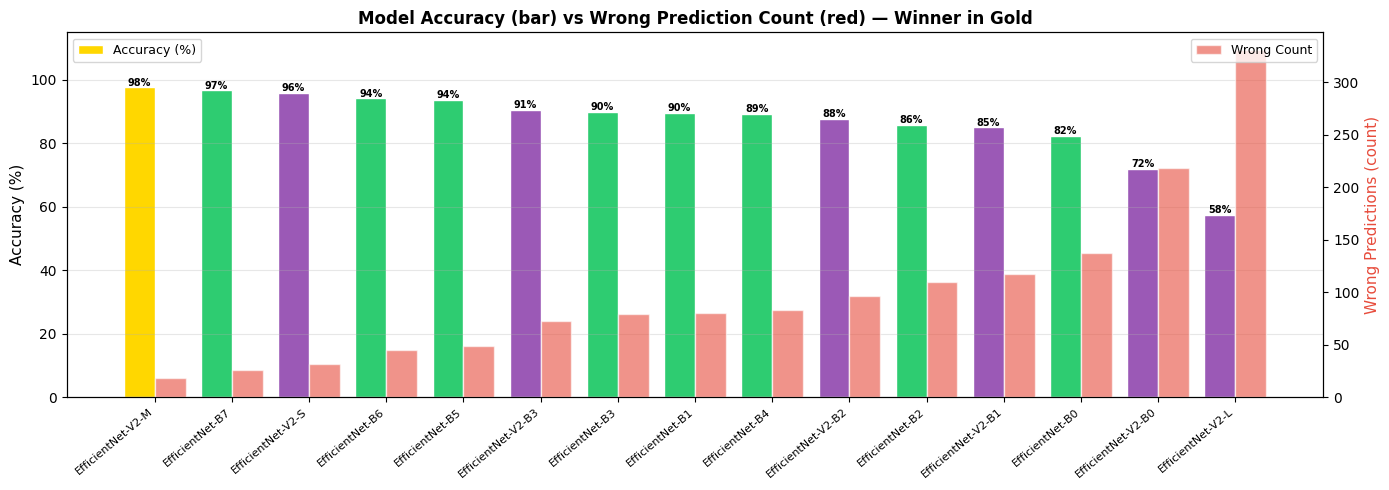

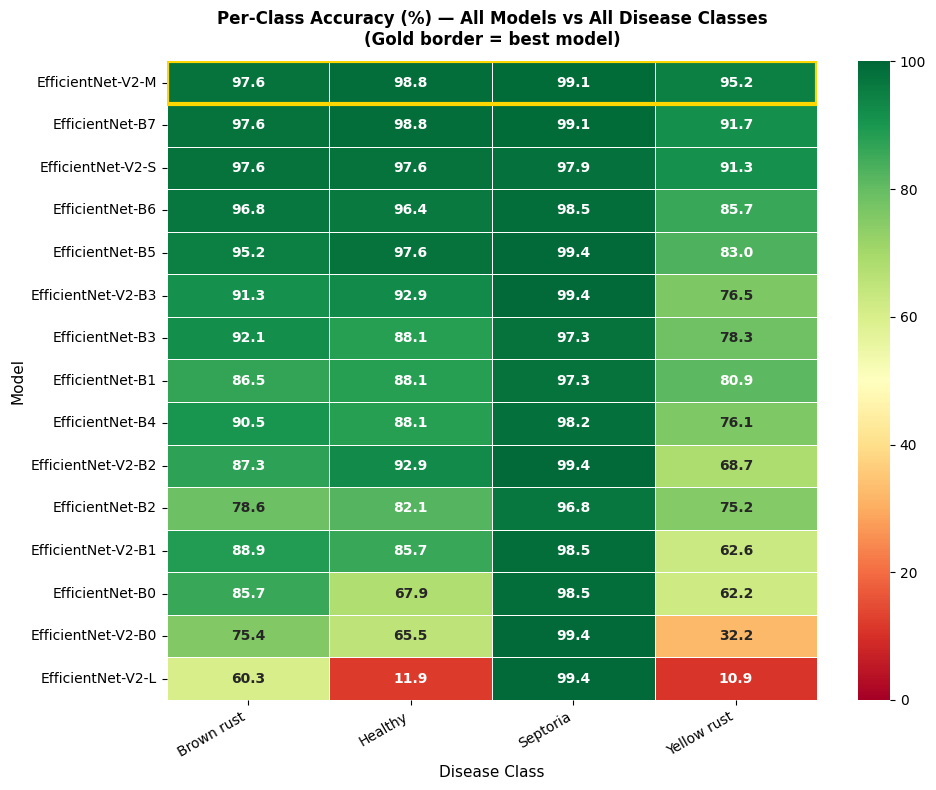

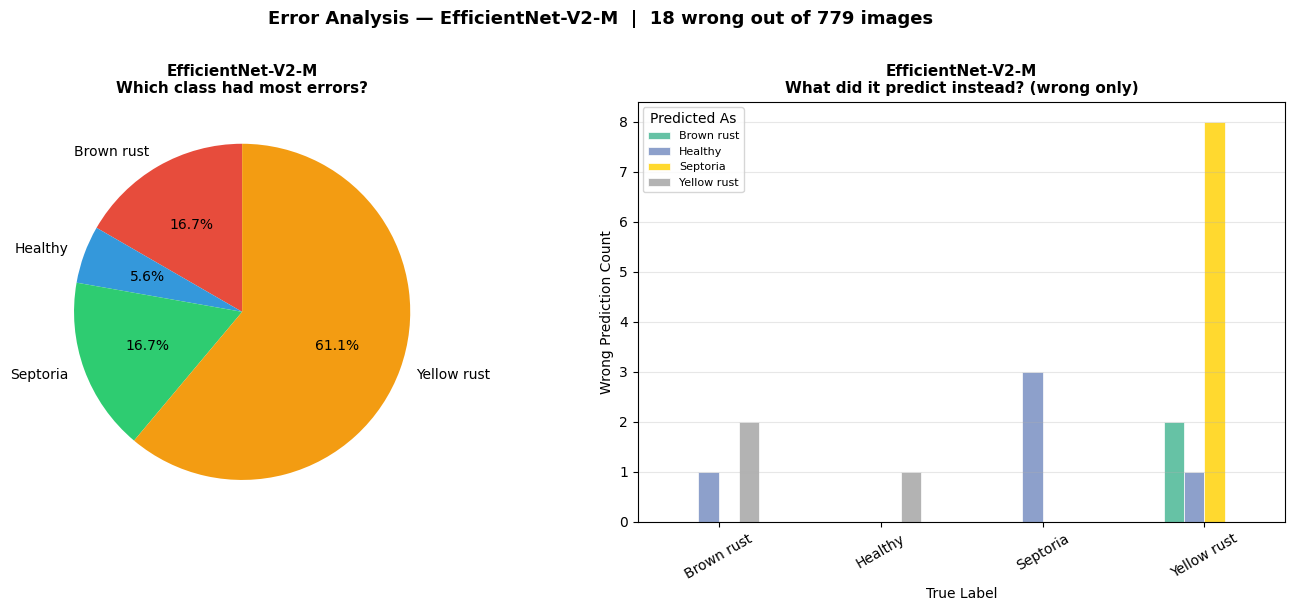


FINAL VERDICT
  Best Model  : EfficientNet-V2-M [V2]
  Accuracy    : 97.7%
  Correct     : 761 / 779
  Wrong       : 18 images
  Avg Conf    : 98.3% on correct predictions

  Winner error breakdown:
    Yellow rust     misclassified as Septoria        -> 8 times
    Septoria        misclassified as Healthy         -> 3 times
    Brown rust      misclassified as Yellow rust     -> 2 times
    Yellow rust     misclassified as Brown rust      -> 2 times
    Brown rust      misclassified as Healthy         -> 1 times
    Healthy         misclassified as Yellow rust     -> 1 times
    Yellow rust     misclassified as Healthy         -> 1 times

  Full report  -> /home/jupyter-kritika/wheat-project/results/test_results_full.xlsx
  Plots saved  -> ./plots


In [34]:
# ═══════════════════════════════════════════════════════════════════
# TEST INFERENCE + EVALUATION — Final Clean Version
# ═══════════════════════════════════════════════════════════════════
import subprocess, sys
subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'openpyxl', '-q'])
import os, re
import torch
import torch.nn.functional as F
from PIL import Image, ImageFile
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import openpyxl
from openpyxl.styles import PatternFill, Font, Alignment, Border, Side
from openpyxl.utils import get_column_letter
from collections import defaultdict

ImageFile.LOAD_TRUNCATED_IMAGES = True

TEST_DIR = "/home/jupyter-kritika/wheat-project/data/test"

# ─────────────────────────────────────────────────────────────────
# STEP 1 — Filename -> True Label Mapping
# ─────────────────────────────────────────────────────────────────
PREFIX_MAP = {
    'brownrust'  : 'Brown rust',
    'healthy'    : 'Healthy',
    'loosesmut'  : 'Loose Smut',
    'septoria'   : 'Septoria',
    'yellowrust' : 'Yellow rust',
}

def extract_true_label(filename):
    name       = os.path.splitext(filename)[0].lower()
    name_clean = re.sub(r'\d+$', '', name).strip()
    return PREFIX_MAP.get(name_clean, None)

# ─────────────────────────────────────────────────────────────────
# STEP 2 — Collect images, show top 5 per class only
#           Everything is still processed — just not printed
# ─────────────────────────────────────────────────────────────────
image_files = [
    f for f in os.listdir(TEST_DIR)
    if f.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.webp'))
]
print(f"Found {len(image_files)} test images\n")

# Group by class
class_buckets = defaultdict(list)
skipped       = []
for f in sorted(image_files):
    label = extract_true_label(f)
    if label is None:
        skipped.append(f)
    else:
        class_buckets[label].append(f)

valid_images = []
for cls in sorted(class_buckets.keys()):
    valid_images.extend(class_buckets[cls])

# Print ONLY top 5 per class — rest processed silently
print(f"{'Filename':<30} {'True Label'}")
print("-" * 55)
for cls in sorted(class_buckets.keys()):
    imgs = class_buckets[cls]
    for i, f in enumerate(imgs):
        if i < 5:
            print(f"  OK  {f:<28} -> {cls}")
        elif i == 5:
            remaining = len(imgs) - 5
            print(f"        ... ({remaining} more '{cls}' images — processed silently)")
            break   # stop printing, but all are in valid_images

if skipped:
    print(f"\n  WARNING: {len(skipped)} files skipped (could not parse label)")

# Class count summary
print(f"\nDataset breakdown:")
total_valid = 0
for cls in sorted(class_buckets.keys()):
    n = len(class_buckets[cls])
    total_valid += n
    print(f"  {cls:<15} : {n:>4} images")
print(f"  {'TOTAL':<15} : {total_valid:>4} valid  |  {len(skipped)} skipped")
print(f"\nAll {total_valid} images will be processed. Detailed per-image results saved to Excel only.\n")

# ─────────────────────────────────────────────────────────────────
# STEP 3 — Run All Models (no per-image printing — saved to file)
# ─────────────────────────────────────────────────────────────────
results = []

for model_name in MODEL_REGISTRY:
    print(f"Running: {model_name:<28}", end=" ")
    img_size, model_fn, batch_override = MODEL_REGISTRY[model_name]

    model     = build_model(model_fn, CONFIG['num_classes'], freeze_backbone=False).to(device)
    ckpt_path = os.path.join(CONFIG['save_dir'], f"best_{model_name}.pth")

    if not os.path.exists(ckpt_path):
        print("WARNING: checkpoint missing, skipped")
        continue

    model.load_state_dict(torch.load(ckpt_path, map_location=device)['model_state'])
    model.eval()
    transform = get_transforms(img_size, 'val')

    correct_count = 0
    for img_name in valid_images:
        true_label = extract_true_label(img_name)
        img_path   = os.path.join(TEST_DIR, img_name)
        img        = Image.open(img_path).convert("RGB")
        x          = transform(img).unsqueeze(0).to(device)

        with torch.no_grad():
            output     = model(x)
            probs      = F.softmax(output, dim=1)
            pred_idx   = probs.argmax(1).item()
            confidence = float(probs.max())
            pred_label = CLASSES[pred_idx]
            is_correct = pred_label == true_label
            if is_correct:
                correct_count += 1

        results.append({
            "Model"      : model_name,
            "Family"     : "V1" if model_name in V1_MODELS else "V2",
            "Image"      : img_name,
            "True Label" : true_label,
            "Predicted"  : pred_label,
            "Correct"    : is_correct,
            "Confidence" : round(confidence * 100, 2),
        })

    acc = round(correct_count / len(valid_images) * 100, 1)
    print(f"-> {correct_count}/{len(valid_images)} correct ({acc}%)")
    torch.cuda.empty_cache()

df = pd.DataFrame(results)
# Save raw predictions silently — no printing
df.to_csv("/home/jupyter-kritika/wheat-project/results/test_predictions_clean.csv", index=False)
print(f"\nRaw predictions saved to CSV ({len(df)} rows).")

# ─────────────────────────────────────────────────────────────────
# STEP 4 — Model Summary Leaderboard
#           Columns: Rank | Model | Family | Total | Correct |
#                    Wrong | Accuracy | Avg Conf (All) | Avg Conf (Correct)
# ─────────────────────────────────────────────────────────────────
summary_data = (
    df.groupby(["Model", "Family"])
    .apply(lambda g: pd.Series({
        "Total"        : len(g),
        "Correct"      : int(g["Correct"].sum()),
        "Wrong"        : int((~g["Correct"]).sum()),
        "Accuracy"     : round(g["Correct"].mean() * 100, 1),
        "Avg_Conf_All" : round(g["Confidence"].mean(), 1),
        "Avg_Conf_Cor" : round(g[g["Correct"]]["Confidence"].mean(), 1)
                         if g["Correct"].any() else 0.0,
    }), include_groups=False)
    .reset_index()
    .sort_values("Accuracy", ascending=False)
    .reset_index(drop=True)
)

# Print clean leaderboard
print("\n" + "=" * 78)
print("MODEL LEADERBOARD — Sorted by Accuracy")
print("=" * 78)
print(f"{'Rank':<5} {'Model':<28} {'Family':<7} {'Total':>6} "
      f"{'Correct':>8} {'Wrong':>6} {'Accuracy':>10} {'Conf(Correct)':>14}")
print("-" * 78)
for i, row in summary_data.iterrows():
    medal = ["#1 ", "#2 ", "#3 "][i] if i < 3 else f"#{i+1:<2}"
    print(f"{medal:<5} {row['Model']:<28} {row['Family']:<7} "
          f"{int(row['Total']):>6} {int(row['Correct']):>8} "
          f"{int(row['Wrong']):>6} {row['Accuracy']:>9.1f}% "
          f"{row['Avg_Conf_Cor']:>13.1f}%")

winner = summary_data.iloc[0]['Model']
print(f"\nOVERALL BEST MODEL: {winner} "
      f"({summary_data.iloc[0]['Accuracy']}% | "
      f"{int(summary_data.iloc[0]['Correct'])}/{int(summary_data.iloc[0]['Total'])} correct | "
      f"{int(summary_data.iloc[0]['Wrong'])} wrong)")

# ─────────────────────────────────────────────────────────────────
# STEP 5 — Winner's Wrong Predictions (printed as compact summary)
#           Full details saved to Excel Sheet 4
# ─────────────────────────────────────────────────────────────────
winner_wrong = (
    df[(df['Model'] == winner) & (df['Correct'] == False)]
    .copy()
    .sort_values('Confidence', ascending=False)
    .reset_index(drop=True)
)
winner_wrong.index += 1

# Error pattern summary only — no per-image printing
error_summary = (
    winner_wrong.groupby(['True Label', 'Predicted'])
    .size()
    .reset_index(name='Count')
    .sort_values('Count', ascending=False)
)

print(f"\n{'='*60}")
print(f"WINNER ERROR SUMMARY — {winner}")
print(f"Total wrong: {len(winner_wrong)} / {int(summary_data.iloc[0]['Total'])}")
print(f"{'='*60}")
print(f"{'True Label':<18} {'Predicted As':<18} {'Count':>6}")
print("-" * 45)
for _, erow in error_summary.iterrows():
    print(f"  {erow['True Label']:<16} -> {erow['Predicted']:<16}  {erow['Count']:>4}")
print(f"\nFull wrong-prediction details saved to Excel Sheet 4.")

# ─────────────────────────────────────────────────────────────────
# STEP 6 — Save to Excel (4 sheets, nothing printed)
# ─────────────────────────────────────────────────────────────────
models_list  = list(summary_data['Model'])
images_list  = sorted(df['Image'].unique())
classes_list = sorted(df['True Label'].unique())

wb = openpyxl.Workbook()

# Shared styles
hdr_fill    = PatternFill("solid", fgColor="1F4E79")
hdr_font    = Font(bold=True, color="FFFFFF", size=10)
green_fill  = PatternFill("solid", fgColor="C6EFCE")
red_fill    = PatternFill("solid", fgColor="FFC7CE")
yellow_fill = PatternFill("solid", fgColor="FFEB9C")
gold_fill   = PatternFill("solid", fgColor="FFD700")
silver_fill = PatternFill("solid", fgColor="C0C0C0")
bronze_fill = PatternFill("solid", fgColor="CD7F32")
blue_fill   = PatternFill("solid", fgColor="D6E4F0")
center      = Alignment(horizontal="center", vertical="center", wrap_text=True)
thin        = Border(
    left=Side(style='thin'), right=Side(style='thin'),
    top=Side(style='thin'),  bottom=Side(style='thin')
)

# ── SHEET 1: Prediction Matrix ────────────────────────────────────
ws1      = wb.active
ws1.title = "Prediction Matrix"

# Header row
for col_idx, label in enumerate(["Image", "True Label"] + models_list, start=1):
    c           = ws1.cell(1, col_idx, label)
    c.font      = hdr_font
    c.fill      = hdr_fill
    c.alignment = center
    c.border    = thin
    # Gold header for winner column
    if label == winner:
        c.fill = gold_fill
        c.font = Font(bold=True, color="000000", size=10)

# Data rows — grouped by class with separator rows
row_idx = 2
for cls in sorted(class_buckets.keys()):
    # Class separator
    for col in range(1, len(models_list) + 3):
        c           = ws1.cell(row_idx, col, cls if col == 1 else "")
        c.fill      = blue_fill
        c.font      = Font(bold=True, size=10)
        c.alignment = center
        c.border    = thin
    row_idx += 1

    for img_name in class_buckets[cls]:
        true_label = extract_true_label(img_name)

        # Image name
        c           = ws1.cell(row_idx, 1, img_name)
        c.alignment = center
        c.border    = thin

        # True label
        c           = ws1.cell(row_idx, 2, true_label)
        c.font      = Font(bold=True)
        c.alignment = center
        c.border    = thin

        # Each model's prediction
        for col_idx, mname in enumerate(models_list, start=3):
            row_data = df[(df['Image'] == img_name) & (df['Model'] == mname)]
            if row_data.empty:
                ws1.cell(row_idx, col_idx, "N/A")
                continue
            predicted  = row_data['Predicted'].iloc[0]
            confidence = row_data['Confidence'].iloc[0]
            correct    = row_data['Correct'].iloc[0]
            c           = ws1.cell(row_idx, col_idx,
                                   f"{predicted}\n({confidence:.1f}%)")
            c.fill      = green_fill if correct else red_fill
            c.alignment = center
            c.border    = thin

        row_idx += 1

# Column widths + freeze
ws1.column_dimensions['A'].width = 24
ws1.column_dimensions['B'].width = 16
for col_idx in range(3, len(models_list) + 3):
    ws1.column_dimensions[get_column_letter(col_idx)].width = 20
for r in range(1, row_idx):
    ws1.row_dimensions[r].height = 36
ws1.freeze_panes = "C2"

# ── SHEET 2: Model Summary (Leaderboard) ─────────────────────────
ws2 = wb.create_sheet("Model Summary")
hdrs2 = ["Rank", "Model", "Family", "Total", "Correct",
         "Wrong", "Accuracy (%)", "Avg Conf All (%)", "Avg Conf Correct (%)"]
for col_idx, h in enumerate(hdrs2, start=1):
    c = ws2.cell(1, col_idx, h)
    c.font = hdr_font; c.fill = hdr_fill
    c.alignment = center; c.border = thin

for i, row in summary_data.iterrows():
    r    = i + 2
    vals = [
        i + 1,
        row['Model'],
        row['Family'],
        int(row['Total']),
        int(row['Correct']),
        int(row['Wrong']),
        row['Accuracy'],
        row['Avg_Conf_All'],
        row['Avg_Conf_Cor'],
    ]
    row_fill = (gold_fill   if i == 0 else
                silver_fill if i == 1 else
                bronze_fill if i == 2 else None)
    for col_idx, val in enumerate(vals, start=1):
        c           = ws2.cell(r, col_idx, val)
        c.alignment = center
        c.border    = thin
        if row_fill:
            c.fill = row_fill
        # Red tint for Wrong column only if no medal color applied
        if col_idx == 6 and isinstance(val, int) and val > 0 and row_fill is None:
            c.fill = red_fill

for col_idx, w in enumerate([6, 28, 8, 8, 10, 8, 14, 18, 22], start=1):
    ws2.column_dimensions[get_column_letter(col_idx)].width = w
ws2.row_dimensions[1].height = 30

# ── SHEET 3: Per Class Accuracy ───────────────────────────────────
ws3 = wb.create_sheet("Per Class Accuracy")
hdrs3 = ["Model", "Family"] + classes_list + ["Overall (%)"]
for col_idx, h in enumerate(hdrs3, start=1):
    c = ws3.cell(1, col_idx, h)
    c.font = hdr_font; c.fill = hdr_fill
    c.alignment = center; c.border = thin

for i, row in summary_data.iterrows():
    r        = i + 2
    model_df = df[df['Model'] == row['Model']]

    ws3.cell(r, 1, row['Model']).alignment = center
    ws3.cell(r, 1).border = thin
    ws3.cell(r, 1).font   = Font(bold=True if row['Model'] == winner else False)
    ws3.cell(r, 2, row['Family']).alignment = center
    ws3.cell(r, 2).border = thin

    for col_idx, cls in enumerate(classes_list, start=3):
        cls_df = model_df[model_df['True Label'] == cls]
        if len(cls_df) == 0:
            acc  = "N/A"
            fill = PatternFill("solid", fgColor="F2F2F2")
        else:
            acc  = round(cls_df['Correct'].mean() * 100, 1)
            fill = (green_fill  if acc >= 80 else
                    yellow_fill if acc >= 50 else
                    red_fill)
        c           = ws3.cell(r, col_idx, acc)
        c.fill      = fill
        c.alignment = center
        c.border    = thin

    overall     = round(model_df['Correct'].mean() * 100, 1)
    c           = ws3.cell(r, len(classes_list) + 3, overall)
    c.font      = Font(bold=True)
    c.alignment = center
    c.border    = thin
    c.fill      = (green_fill  if overall >= 80 else
                   yellow_fill if overall >= 60 else
                   red_fill)

for col_idx in range(1, len(hdrs3) + 1):
    ws3.column_dimensions[get_column_letter(col_idx)].width = 18
ws3.row_dimensions[1].height = 30

# ── SHEET 4: Winner's Wrong Predictions ──────────────────────────
ws4 = wb.create_sheet("Winner Wrong Predictions")

# Title
title_cell = ws4.cell(1, 1,
    f"Model: {winner}  —  Wrong Predictions: {len(winner_wrong)} / "
    f"{int(summary_data.iloc[0]['Total'])}  "
    f"(Accuracy: {summary_data.iloc[0]['Accuracy']}%)")
title_cell.font = Font(bold=True, size=12, color="CC0000")
ws4.merge_cells(f"A1:F1")
ws4.row_dimensions[1].height = 25

# Column headers
hdrs4 = ["#", "Image", "True Label", "Predicted As",
         "Confidence (%)", "Error Type"]
for col_idx, h in enumerate(hdrs4, start=1):
    c = ws4.cell(2, col_idx, h)
    c.font = hdr_font; c.fill = hdr_fill
    c.alignment = center; c.border = thin

# One row per wrong prediction
for i, row in winner_wrong.iterrows():
    r          = i + 2
    error_type = f"{row['True Label']} mistaken as {row['Predicted']}"
    vals       = [i, row['Image'], row['True Label'],
                  row['Predicted'], row['Confidence'], error_type]
    for col_idx, val in enumerate(vals, start=1):
        c           = ws4.cell(r, col_idx, val)
        c.alignment = center
        c.border    = thin
        if col_idx == 3: c.fill = green_fill   # true label
        if col_idx == 4: c.fill = red_fill      # wrong prediction

# Error pattern summary table below the list
gap = len(winner_wrong) + 4
ws4.cell(gap, 1, "Error Pattern Summary").font = Font(bold=True, size=11)
ws4.merge_cells(f"A{gap}:F{gap}")
gap += 1

for col_idx, h in enumerate(["True Label", "Predicted As", "Count"], start=1):
    c = ws4.cell(gap, col_idx, h)
    c.font = hdr_font; c.fill = hdr_fill
    c.alignment = center; c.border = thin
gap += 1

for _, erow in error_summary.iterrows():
    ws4.cell(gap, 1, erow['True Label']).fill      = green_fill
    ws4.cell(gap, 1).alignment = center; ws4.cell(gap, 1).border = thin
    ws4.cell(gap, 2, erow['Predicted']).fill       = red_fill
    ws4.cell(gap, 2).alignment = center; ws4.cell(gap, 2).border = thin
    ws4.cell(gap, 3, int(erow['Count'])).alignment = center
    ws4.cell(gap, 3).border = thin
    gap += 1

for col_idx, w in enumerate([5, 26, 16, 16, 16, 36], start=1):
    ws4.column_dimensions[get_column_letter(col_idx)].width = w
ws4.freeze_panes = "A3"

# ── Save ─────────────────────────────────────────────────────────
output_path = "/home/jupyter-kritika/wheat-project/results/test_results_full.xlsx"
wb.save(output_path)
print(f"\nExcel saved -> {output_path}")
print(f"  Sheet 1 — Prediction Matrix      : {len(images_list)} images x {len(models_list)} models")
print(f"  Sheet 2 — Model Summary          : leaderboard with Total / Correct / Wrong")
print(f"  Sheet 3 — Per Class Accuracy     : green/yellow/red by disease class")
print(f"  Sheet 4 — Winner Wrong Preds     : {len(winner_wrong)} wrong images from {winner}")

# ─────────────────────────────────────────────────────────────────
# STEP 7 — VISUALIZATIONS (clean, no clustering)
# ─────────────────────────────────────────────────────────────────

# --- 7A: Accuracy + Wrong count grouped bar ---
fig, ax1 = plt.subplots(figsize=(14, 5))
x      = np.arange(len(summary_data))
width  = 0.4
colors = ['#FFD700' if m == winner else
          ('#2ecc71' if summary_data[summary_data['Model']==m]['Family'].iloc[0]=='V1'
           else '#9b59b6')
          for m in summary_data['Model']]

bars = ax1.bar(x - width/2, summary_data['Accuracy'],
               width=width, color=colors, edgecolor='white', label='Accuracy (%)')
ax2  = ax1.twinx()
ax2.bar(x + width/2, summary_data['Wrong'],
        width=width, color='#e74c3c', alpha=0.6,
        edgecolor='white', label='Wrong Count')

for bar, val in zip(bars, summary_data['Accuracy']):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{val:.0f}%', ha='center', fontsize=7, fontweight='bold')

ax1.set_xticks(x)
ax1.set_xticklabels(summary_data['Model'], rotation=40, ha='right', fontsize=8)
ax1.set_ylim(0, 115)
ax1.set_ylabel('Accuracy (%)', fontsize=11)
ax2.set_ylabel('Wrong Predictions (count)', fontsize=11, color='#e74c3c')
ax1.set_title('Model Accuracy (bar) vs Wrong Prediction Count (red) — Winner in Gold',
              fontsize=12, fontweight='bold')
ax1.grid(axis='y', alpha=0.3)
ax1.legend(loc='upper left', fontsize=9)
ax2.legend(loc='upper right', fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(CONFIG['plots_dir'], 'test_accuracy_wrong_bar.png'), dpi=150)
plt.show()

# --- 7B: Per-Class Accuracy Heatmap (15 models x 5 classes) ---
class_acc_matrix = []
for mname in summary_data['Model']:
    row_vals = []
    model_df = df[df['Model'] == mname]
    for cls in classes_list:
        cls_df = model_df[model_df['True Label'] == cls]
        row_vals.append(round(cls_df['Correct'].mean() * 100, 1)
                        if len(cls_df) > 0 else np.nan)
    class_acc_matrix.append(row_vals)

class_acc_df = pd.DataFrame(
    class_acc_matrix,
    index=summary_data['Model'],
    columns=classes_list
)
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(class_acc_df, annot=True, fmt='.1f', cmap='RdYlGn',
            linewidths=0.5, vmin=0, vmax=100, ax=ax,
            annot_kws={'size': 10, 'weight': 'bold'})
# Gold border around winner row
winner_idx = list(summary_data['Model']).index(winner)
ax.add_patch(plt.Rectangle(
    (0, winner_idx), len(classes_list), 1,
    fill=False, edgecolor='gold', lw=3, zorder=5
))
ax.set_title('Per-Class Accuracy (%) — All Models vs All Disease Classes\n(Gold border = best model)',
             fontsize=12, fontweight='bold', pad=12)
ax.set_xlabel('Disease Class', fontsize=11)
ax.set_ylabel('Model', fontsize=11)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig(os.path.join(CONFIG['plots_dir'], 'per_class_accuracy_heatmap.png'), dpi=150)
plt.show()

# --- 7C: Winner Error Analysis ---
if len(winner_wrong) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # Pie: errors by true class
    error_counts = winner_wrong.groupby('True Label').size()
    axes[0].pie(
        error_counts.values,
        labels=error_counts.index,
        autopct='%1.1f%%',
        colors=['#e74c3c','#3498db','#2ecc71','#f39c12','#9b59b6'],
        startangle=90,
        textprops={'fontsize': 10}
    )
    axes[0].set_title(f'{winner}\nWhich class had most errors?',
                      fontsize=11, fontweight='bold')

    # Bar: what did it predict instead
    error_pattern = (
        winner_wrong
        .groupby(['True Label', 'Predicted'])
        .size()
        .reset_index(name='Count')
    )
    pivot_err = (
        error_pattern
        .pivot(index='True Label', columns='Predicted', values='Count')
        .fillna(0)
    )
    pivot_err.plot(kind='bar', ax=axes[1], colormap='Set2',
                   edgecolor='white', linewidth=0.5)
    axes[1].set_title(f'{winner}\nWhat did it predict instead? (wrong only)',
                      fontsize=11, fontweight='bold')
    axes[1].set_xlabel('True Label', fontsize=10)
    axes[1].set_ylabel('Wrong Prediction Count', fontsize=10)
    axes[1].tick_params(axis='x', rotation=30)
    axes[1].legend(title='Predicted As', fontsize=8)
    axes[1].grid(axis='y', alpha=0.3)

    plt.suptitle(
        f'Error Analysis — {winner}  |  {len(winner_wrong)} wrong out of '
        f'{int(summary_data.iloc[0]["Total"])} images',
        fontsize=13, fontweight='bold', y=1.01
    )
    plt.tight_layout()
    plt.savefig(os.path.join(CONFIG['plots_dir'], 'winner_error_analysis.png'), dpi=150)
    plt.show()

# ─────────────────────────────────────────────────────────────────
# STEP 8 — FINAL VERDICT (compact print)
# ─────────────────────────────────────────────────────────────────
print("\n" + "=" * 65)
print("FINAL VERDICT")
print("=" * 65)
best = summary_data.iloc[0]
print(f"  Best Model  : {best['Model']} [{best['Family']}]")
print(f"  Accuracy    : {best['Accuracy']}%")
print(f"  Correct     : {int(best['Correct'])} / {int(best['Total'])}")
print(f"  Wrong       : {int(best['Wrong'])} images")
print(f"  Avg Conf    : {best['Avg_Conf_Cor']}% on correct predictions")
print(f"\n  Winner error breakdown:")
for _, erow in error_summary.iterrows():
    print(f"    {erow['True Label']:<15} misclassified as "
          f"{erow['Predicted']:<15} -> {int(erow['Count'])} times")
print(f"\n  Full report  -> {output_path}")
print(f"  Plots saved  -> {CONFIG['plots_dir']}")

In [ ]:
# ═══════════════════════════════════════════════════════════════════
# VISUALIZE WRONG PREDICTIONS — Winner Model
# Shows the actual images that the best model got wrong
# ═══════════════════════════════════════════════════════════════════

import math
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# winner and winner_wrong are already defined from previous cell
print(f"Showing all {len(winner_wrong)} wrong predictions from: {winner}\n")

# ── Layout: 4 images per row ──────────────────────────────────────
COLS     = 4
n_images = len(winner_wrong)
ROWS     = math.ceil(n_images / COLS)

fig, axes = plt.subplots(ROWS, COLS,
                         figsize=(COLS * 4, ROWS * 4.2))
axes = axes.flatten() if n_images > 1 else [axes]

for i, (_, row) in enumerate(winner_wrong.iterrows()):
    img_path = os.path.join(TEST_DIR, row['Image'])
    img      = Image.open(img_path).convert("RGB")
    ax       = axes[i]

    ax.imshow(img)
    ax.axis('off')

    # Title: filename on top
    ax.set_title(row['Image'], fontsize=7, color='gray', pad=2)

    # Bottom label box — True vs Predicted
    label_text = (
        f"True:  {row['True Label']}\n"
        f"Pred:  {row['Predicted']}  ({row['Confidence']:.1f}%)"
    )
    ax.text(
        0.5, -0.04, label_text,
        transform=ax.transAxes,
        fontsize=8, ha='center', va='top',
        color='white',
        bbox=dict(boxstyle='round,pad=0.4',
                  facecolor='#c0392b',   # red background
                  edgecolor='white',
                  linewidth=0.8)
    )

# Hide unused subplots
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.suptitle(
    f"Wrong Predictions — {winner}\n"
    f"{n_images} images misclassified  |  "
    f"Red box = True Label -> Predicted As (Confidence%)",
    fontsize=13, fontweight='bold', y=1.01
)
plt.tight_layout(h_pad=3.5, w_pad=1.5)
plt.savefig(
    os.path.join(CONFIG['plots_dir'], 'winner_wrong_images.png'),
    dpi=120, bbox_inches='tight'
)
plt.show()

print(f"Saved -> {CONFIG['plots_dir']}/winner_wrong_images.png")

Showing all 18 wrong predictions from: EfficientNet-V2-M

